# 🏴‍☠️ Pirate Pain Classification Challenge

> ⚓ *"Even pirates feel pain — let's teach the model to feel it too."*

---

## 📚 Table of Contents
0. [README](#readme)  
1. [Setup & Configuration](#setup)  
2. [Data Loading](#data-loading)  
3. [Import Libraries](#import-libraries)  
4. [Data Preprocessing](#data-preprocessing)  
5. [Sequence Building](#sequence-building)  
6. [DataLoaders](#dataloaders)  
7. [Network Hyperparameters](#hyperparameters)
8. [Model Architecture](#model-architecture)  
9. [Training Functions](#training-functions)  
10. [Model Training](#model-training)  
11. [Evaluation & Metrics](#evaluation)  
12. [Model Loading & Final Testing](#model-loading)  
13. [Competition Submission](#submission)

---

### ⚙️ Quick Configuration Map

> 🧭 *"If ye seek to tweak the code, here be where to look!"*

- 🧺 **Batch Size:** → [DataLoaders](#dataloaders)  
- ⚗️ **Hyperparameters:** → [Network Hyperparameters](#hyperparameters)  
- 🪞 **Window Size & Stride:** → [Sequence Building](#sequence-building)  
- ⚙️ **Model Type:** → [Setup & Configuration](#setup)  

---



---

### 💰 Treasure Storage — Models & Submissions
> 🏴‍☠️ *"A wise pirate always knows where his treasure be buried — guard yer models and submissions well!"*

- 💾 **Model & Submission Save/Load Path:** → [Setup & Configuration](#setup)  
  - 🗂️ Models be saved in a **`models/`** folder with the name:
    **`experiment_name_dd-mm-HH-MM.pt`** (day-month-hour-minute).
  - 📜 Submissions be saved in a **`submissions/`** folder with the filename format:  
    **`experiment_name_dd-mm-HH-MM.csv`** .
  - 🔡 All related model parameters are saved in **`models/`** folder with the  name **`experiment_name_dd-mm-HH-MM_config.json`** .

  
  *❗The experiment name is set as **`RnnType_Bi_dd-mm-HH-MM`** or **`RnnType_dd-mm-HH-MM`** depending on if it is bidirectional or not*
---






In [1]:
RNN_TYPE = 'RNN'            # 'RNN', 'LSTM', or 'GRU'
BIDIRECTIONAL = True        # True / False

In [2]:
from datetime import datetime

# Get current date and time for submission filename
current_datetime = datetime.now().strftime("%d-%m-%H-%M")

if BIDIRECTIONAL:
    EXPERIMENT_NAME = f"{RNN_TYPE}_bi_{current_datetime}"
else:
    EXPERIMENT_NAME = f"{RNN_TYPE}_{current_datetime}"

SUBMISSION_FILENAME = f"{EXPERIMENT_NAME}.csv"
print(f"Experiment name: {EXPERIMENT_NAME}")
print(f"Submission filename: {SUBMISSION_FILENAME}")

Experiment name: RNN_bi_16-11-21-55
Submission filename: RNN_bi_16-11-21-55.csv


In [3]:
import pandas as pd

X_train = pd.read_csv('an2dl2526c1/pirate_pain_train.csv')
X_test = pd.read_csv('an2dl2526c1/pirate_pain_test.csv')

y_train = pd.read_csv('an2dl2526c1/pirate_pain_train_labels.csv')

In [4]:
# Set seed for reproducibility
SEED = 42

# Import necessary libraries
import os

# Set environment variables before importing modules
os.environ['PYTHONHASHSEED'] = str(SEED)
os.environ['MPLCONFIGDIR'] = os.getcwd() + '/configs/'

# Suppress warnings
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)
warnings.simplefilter(action='ignore', category=Warning)

# Import necessary modules
import logging
import random
import numpy as np

# Set seeds for random number generators in NumPy and Python
np.random.seed(SEED)
random.seed(SEED)

# Import PyTorch
import torch
torch.manual_seed(SEED)
from torch import nn
from torchsummary import summary
from torch.utils.tensorboard import SummaryWriter
from torch.utils.data import TensorDataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau

# Directory configuration
logs_dir = "tensorboard"
models_dir = "models"

models_dir = "models/"

# Model save/load paths
MODEL_SAVE_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"
MODEL_LOAD_PATH = f"{models_dir}/{EXPERIMENT_NAME}_model.pt"

!pkill -f tensorboard
%load_ext tensorboard
!mkdir -p {models_dir}

if torch.cuda.is_available():
    device = torch.device("cuda")
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
else:
    device = torch.device("cpu")

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {device}")

# Import other libraries
import copy
import shutil
from datetime import datetime
from itertools import product
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import torch.nn.functional as F
import torch.optim as optim

# Configure plot display settings
sns.set(font_scale=1.4)
sns.set_style('white')
plt.rc('font', size=14)
%matplotlib inline

'pkill' is not recognized as an internal or external command,
operable program or batch file.
The syntax of the command is incorrect.


PyTorch version: 2.10.0.dev20251109+cu128
Device: cuda


## Dataset preprocessing

In [5]:
# Print the shape of the dataset
print(f"Dataset shape: {X_train.shape}")

NUM_PIRATES = X_train['sample_index'].nunique()

# Display the first few rows of the dataset
X_train.head(10)

Dataset shape: (105760, 40)


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,n_legs,n_hands,n_eyes,joint_00,...,joint_21,joint_22,joint_23,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30
0,0,0,2,0,2,1,two,two,two,1.094705,...,3.499558e-06,1.945042e-06,3.999558e-06,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0.5
1,0,1,2,2,2,2,two,two,two,1.135183,...,3.976952e-07,6.765107e-07,6.019627e-06,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0.5
2,0,2,2,0,2,2,two,two,two,1.080745,...,1.533820e-07,1.698525e-07,1.446051e-06,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0.5
3,0,3,2,2,2,2,two,two,two,0.938017,...,1.006865e-05,5.511079e-07,1.847597e-06,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0.5
4,0,4,2,2,2,2,two,two,two,1.090185,...,4.437266e-06,1.735459e-07,1.552722e-06,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0.5
5,0,5,2,0,2,1,two,two,two,1.146031,...,1.073167e-06,1.753837e-07,2.957340e-07,6.217311e-08,0.000007,0.006150,0.006444,0.033101,0.023767,0.5
6,0,6,2,1,2,1,two,two,two,1.025870,...,1.074800e-06,1.772156e-07,1.976558e-06,1.576086e-06,0.000005,0.006495,0.006421,0.031804,0.019056,0.5
7,0,7,2,2,2,2,two,two,two,1.038597,...,8.829074e-07,1.790415e-07,2.210562e-06,1.485741e-06,0.000000,0.015998,0.005397,0.035552,0.015732,0.5
8,0,8,2,2,0,1,two,two,two,0.984251,...,1.621055e-06,1.165161e-06,3.030164e-07,5.416678e-07,0.000000,0.020539,0.008517,0.008635,0.015257,0.5
9,0,9,0,2,2,2,two,two,two,1.054999,...,1.609114e-06,3.959558e-06,2.017157e-06,1.154349e-06,0.000007,0.007682,0.021383,0.034006,0.028966,0.5


In [6]:
# Merge features and labels
data = X_train.merge(y_train, on='sample_index')

cols = ['n_legs', 'n_hands', 'n_eyes']
unique_values = {col: X_train[col].unique().tolist() for col in cols}

unique_values

{'n_legs': ['two', 'one+peg_leg'],
 'n_hands': ['two', 'one+hook_hand'],
 'n_eyes': ['two', 'one+eye_patch']}

In [7]:
# Create binary features (1 = has prosthetic, 0 = does not)
df_corr_check = data.copy()
df_corr_check['has_peg_leg'] = np.where(df_corr_check['n_legs'] == 'one+peg_leg', 1, 0)
df_corr_check['has_hook_hand'] = np.where(df_corr_check['n_hands'] == 'one+hook_hand', 1, 0)
df_corr_check['has_eye_patch'] = np.where(df_corr_check['n_eyes'] == 'one+eye_patch', 1, 0)
# Map the Label to numeric for the correlation matrix
label_mapping = {'no_pain': 0, 'low_pain': 1, 'high_pain': 2}
df_corr_check['label'] = df_corr_check['label'].map(label_mapping)
print("Created binary prosthetic features and numeric pain_level.")

Created binary prosthetic features and numeric pain_level.


In [8]:
data = df_corr_check.copy()
data = data.drop(columns=['n_legs', 'n_hands', 'n_eyes'])

data.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,0.000004,0.017592,0.013508,0.026798,0.027815,0.5,0,0,0,0
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,0.000000,0.013352,0.000000,0.013377,0.013716,0.5,0,0,0,0
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,0.000003,0.016225,0.008110,0.024097,0.023105,0.5,0,0,0,0
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,0.000000,0.011832,0.007450,0.028613,0.024648,0.5,0,0,0,0
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,0.000007,0.005360,0.002532,0.033026,0.025328,0.5,0,0,0,0


--- Calculating Correlation Matrix ---


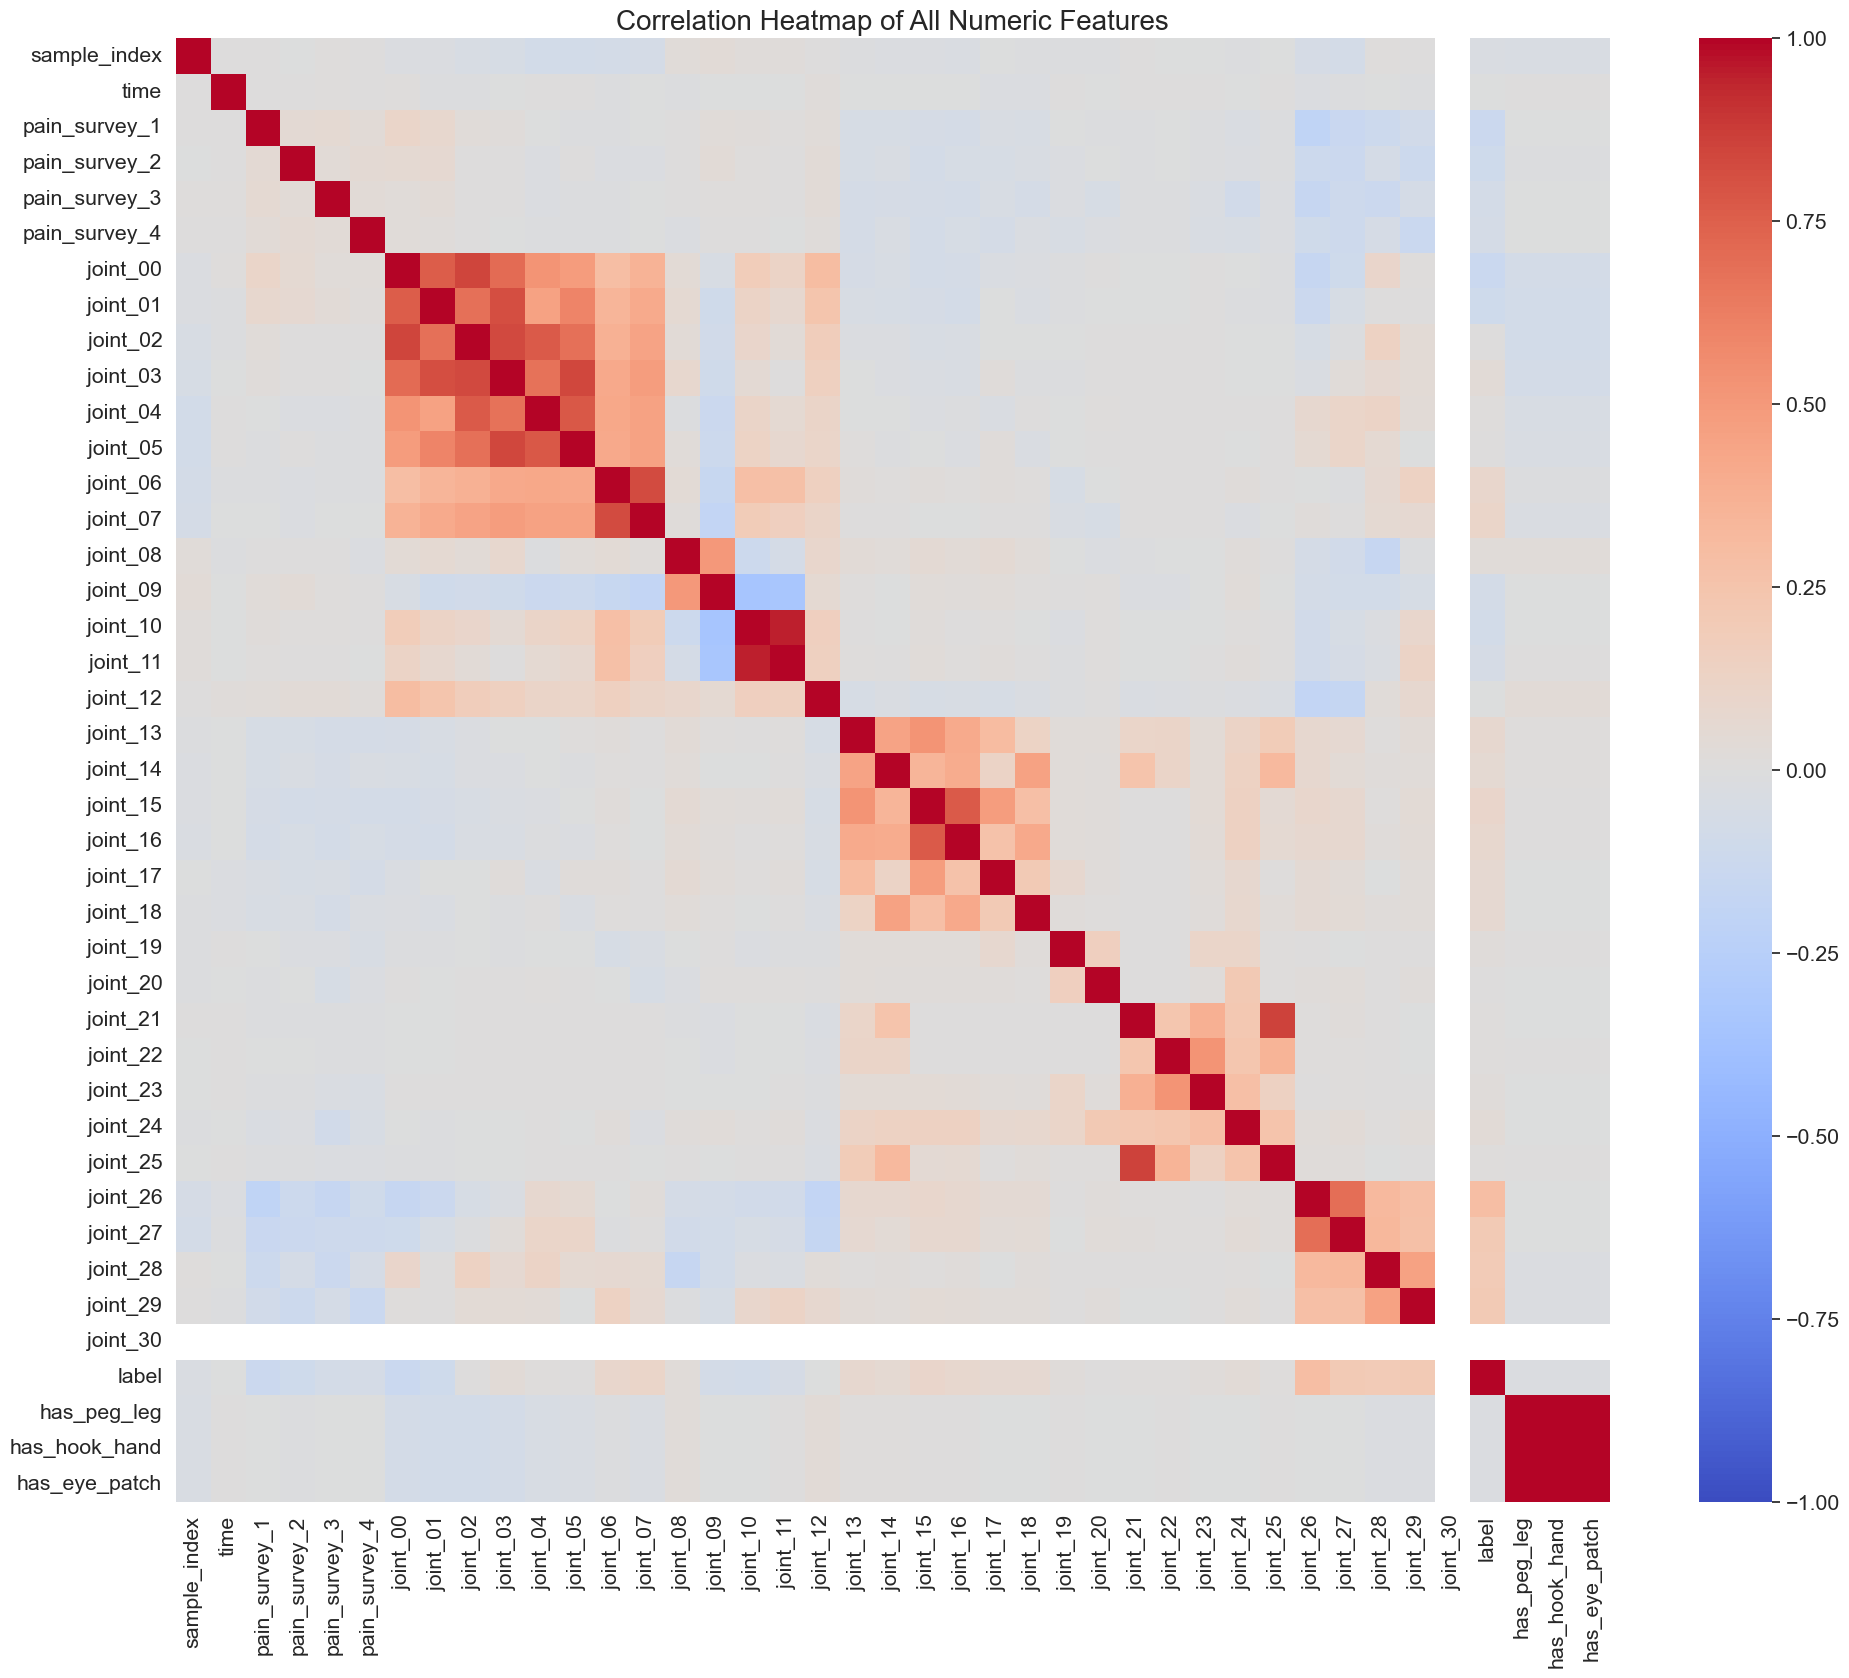

In [9]:
import seaborn as sns

print("--- Calculating Correlation Matrix ---")
# Select all numeric columns for the matrix
df_numeric = df_corr_check.select_dtypes(include=[np.number])
corr_matrix = df_numeric.corr()
# Plot the heatmap
plt.figure(figsize=(20, 17))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Correlation Heatmap of All Numeric Features', fontsize=20)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


--- Verifying the link between spikes and pain ---
Original dataset has 105760 rows.
Found 870 rows (0.82%) with spike events.


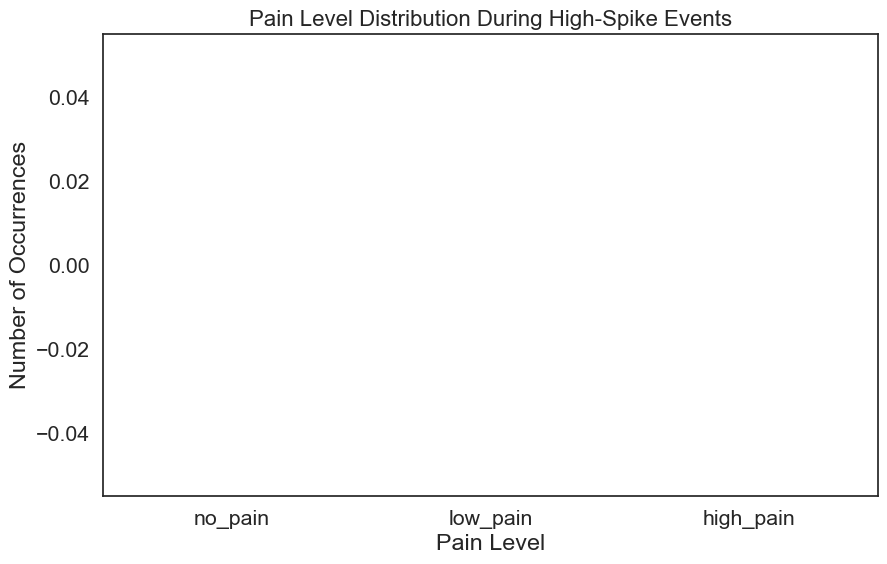


--- Pain distribution during spike events ---
label
0    0.501149
1    0.327586
2    0.171264
Name: proportion, dtype: float64


In [12]:
print("--- Verifying the link between spikes and pain ---")

# Define the same skewed joint columns
skewed_cols = [f'joint_{i:02d}' for i in range(13, 26)]

# Define a spike threshold
spike_thresholds = data[skewed_cols].quantile(0.999)

# Create a boolean mask. A row is True if ANY of the skewed joints exceeds its spike threshold
is_spike_moment = (data[skewed_cols] > spike_thresholds).any(axis=1)

# Create a new DataFrame containing only the rows with spikes
df_spikes = data[is_spike_moment]
print(f"Original dataset has {len(data)} rows.")

print(f"Found {len(df_spikes)} rows ({len(df_spikes)/len(data):.2%}) with spike events.")

plt.figure(figsize=(10, 6))
sns.countplot(x='label', data=df_spikes, order=['no_pain', 'low_pain', 'high_pain'])
plt.title('Pain Level Distribution During High-Spike Events', fontsize=16)
plt.ylabel('Number of Occurrences')
plt.xlabel('Pain Level')
plt.show()
# Print the normalized counts for comparison
print("\n--- Pain distribution during spike events ---")
print(df_spikes['label'].value_counts(normalize=True))

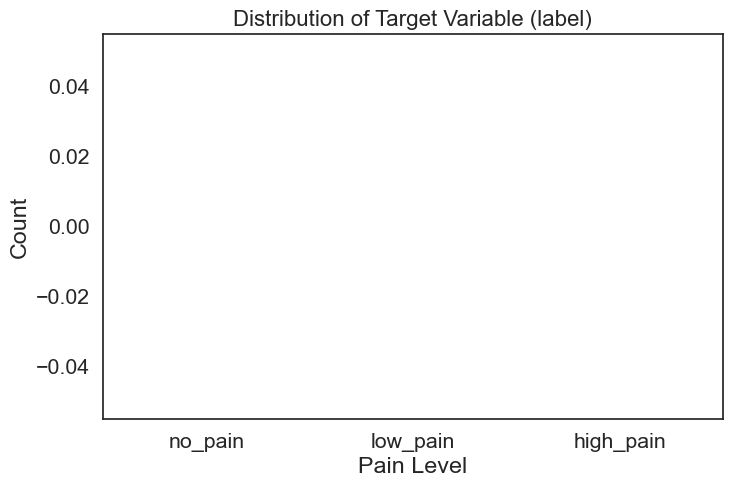

label
0    0.773071
1    0.142209
2    0.084720
Name: proportion, dtype: float64


In [11]:
# Checking the entire data distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='label', data=data, order=['no_pain', 'low_pain', 'high_pain'])
plt.title('Distribution of Target Variable (label)', fontsize=16)
plt.ylabel('Count')
plt.xlabel('Pain Level')
plt.show()
print(data['label'].value_counts(normalize=True))


In [1137]:
data.describe()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,label,has_peg_leg,has_hook_hand,has_eye_patch
count,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,105760.000000,...,1.057600e+05,105760.000000,105760.000000,105760.000000,105760.000000,105760.0,105760.000000,105760.000000,105760.000000,105760.000000
mean,330.000000,79.500000,1.633746,1.654851,1.653640,1.663134,0.943095,0.916955,0.779296,0.767921,...,1.024604e-04,0.041905,0.058244,0.049886,0.062273,0.5,0.311649,0.009077,0.009077,0.009077
std,190.814948,46.187338,0.682423,0.669639,0.666649,0.661994,0.202051,0.197608,0.295605,0.300787,...,3.206128e-03,0.060293,0.079819,0.060773,0.072597,0.0,0.619651,0.094841,0.094841,0.094841
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.001015,0.005403,...,0.000000e+00,0.000203,0.000000,0.000000,0.000000,0.5,0.000000,0.000000,0.000000,0.000000
25%,165.000000,39.750000,2.000000,2.000000,2.000000,2.000000,0.828277,0.811445,0.568850,0.520020,...,7.161332e-07,0.009885,0.012652,0.016290,0.019638,0.5,0.000000,0.000000,0.000000,0.000000
50%,330.000000,79.500000,2.000000,2.000000,2.000000,2.000000,1.005126,0.979468,0.909549,0.914834,...,3.126723e-06,0.021898,0.031739,0.031843,0.039041,0.5,0.000000,0.000000,0.000000,0.000000
75%,495.000000,119.250000,2.000000,2.000000,2.000000,2.000000,1.081039,1.056611,0.995187,0.994324,...,9.946107e-06,0.048579,0.071051,0.058741,0.079518,0.5,0.000000,0.000000,0.000000,0.000000
max,660.000000,159.000000,2.000000,2.000000,2.000000,2.000000,1.407968,1.334613,1.306046,1.254729,...,9.473540e-01,1.223617,1.187419,1.412037,1.370765,0.5,2.000000,1.000000,1.000000,1.000000


In [1138]:
list_to_remove = ['joint_30']

if data.columns.isin(list_to_remove).any():
  data = data.drop(columns=list_to_remove)
  data.head()
else:
  print("Useless features already removed")

In [1139]:
data.head()

,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,label,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0,2,0,2,1,1.094705,0.985281,1.018302,1.010385,...,1.153299e-05,0.000004,0.017592,0.013508,0.026798,0.027815,0,0,0,0
1,0,1,2,2,2,2,1.135183,1.021175,0.994343,1.052364,...,4.643774e-08,0.000000,0.013352,0.000000,0.013377,0.013716,0,0,0,0
2,0,2,2,0,2,2,1.080745,0.962842,1.009588,0.977169,...,2.424536e-06,0.000003,0.016225,0.008110,0.024097,0.023105,0,0,0,0
3,0,3,2,2,2,2,0.938017,1.081592,0.998021,0.987283,...,5.432416e-08,0.000000,0.011832,0.007450,0.028613,0.024648,0,0,0,0
4,0,4,2,2,2,2,1.090185,1.032145,1.008710,0.963658,...,5.825366e-08,0.000007,0.005360,0.002532,0.033026,0.025328,0,0,0,0


In [1140]:
# Count the continouse and categorical features
continuous_cols = []
categorical_cols = []

for col in data.columns:
    if not col.startswith('pain_survey_') and not col.startswith('n_') and not col == 'label':
        continuous_cols.append(col)
    elif col.startswith('n_') or col.startswith('pain_survey_'):
        categorical_cols.append(col)

print(f"Continuous features: {len(continuous_cols)}")
print(f"Categorical features: {len(categorical_cols)}")

Continuous features: 35
Categorical features: 4


In [1141]:
# Define embedding dimensions for categorical features
# For 3 unique values (0, 1, 2), embedding dimension of 2 is reasonable
embedding_dims = {
    'pain_survey_1': 2,
    'pain_survey_2': 2,
    'pain_survey_3': 2,
    'pain_survey_4': 2,
    'has_peg_leg': 1,
    'has_hook_hand': 1,
    'has_eye_patch': 1
}

print(f"Embedding dimensions: {embedding_dims}")
print(f"Total embedding output size: {sum(embedding_dims.values())}")
print(f"Continuous features: {len(continuous_cols)}")
print(f"Total input size to LSTM: {sum(embedding_dims.values()) + len(continuous_cols)}")

Embedding dimensions: {'pain_survey_1': 2, 'pain_survey_2': 2, 'pain_survey_3': 2, 'pain_survey_4': 2, 'has_peg_leg': 1, 'has_hook_hand': 1, 'has_eye_patch': 1}
Total embedding output size: 11
Continuous features: 35
Total input size to LSTM: 46


In [1142]:
# Check the columns and their types
print("Columns in data:")
print(data.columns.tolist())
print("\nData types:")
print(data.dtypes)

Columns in data:
['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'label', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']

Data types:
sample_index       int64
time               int64
pain_survey_1      int64
pain_survey_2      int64
pain_survey_3      int64
pain_survey_4      int64
joint_00         float64
joint_01         float64
joint_02         float64
joint_03         float64
joint_04         float64
joint_05         float64
joint_06         float64
joint_07         float64
joint_08         float64
joint_09         float64
joint_10         float64
joint_11         float64
joint_12 

In [1143]:
data = data.astype(np.float32)

In [1144]:
import pandas as pd
import random
from sklearn.model_selection import train_test_split

# ============================================================
# DATA SPLITTING & BALANCING CONFIGURATION
# ============================================================
N_NO_PAIN_KEEP = 1000   # Max number of "no_pain" pirates for training (for balancing)
N_LOW_PAIN_KEEP = 150   # Max number of "low_pain" pirates for training
N_VAL_USERS = 160       # Number of pirates for validation

# Label mapping for clarity (data uses numeric labels: 0.0, 1.0, 2.0)
LABEL_MAPPING = {0.0: 'no_pain', 1.0: 'low_pain', 2.0: 'high_pain'}
REVERSE_LABEL_MAPPING = {'no_pain': 0.0, 'low_pain': 1.0, 'high_pain': 2.0}

print("=" * 60)
print("STEP 1: Computing dominant label per pirate")
print("=" * 60)

# Compute each pirate's dominant label (most frequent label in their sequences)
user_labels = (
    data.groupby('sample_index')['label']
    .agg(lambda x: x.value_counts().index[0])  # Get most common label
    .reset_index()
)

# Convert numeric labels to string labels for better readability
user_labels['label_str'] = user_labels['label'].map(LABEL_MAPPING)

print(f"\n📊 Original label distribution:")
print(user_labels['label_str'].value_counts().to_dict())

# ============================================================
# STEP 2: Stratified Split (Train/Val only - no test set)
# ============================================================
print("\n" + "=" * 60)
print("STEP 2: Stratified split into Train/Val")
print("=" * 60)

# Split into training and validation only
train_users, val_users = train_test_split(
    user_labels['sample_index'],
    test_size=N_VAL_USERS / len(user_labels),
    stratify=user_labels['label'],  # Stratify by numeric label
    random_state=42  # Fixed seed for reproducibility
)

print(f"✅ Initial splits created:")
print(f"   • Training pirates: {len(train_users)}")
print(f"   • Validation pirates: {len(val_users)}")

# ============================================================
# STEP 3: Balance Training Set (Custom Undersampling)
# ============================================================
print("\n" + "=" * 60)
print("STEP 3: Balancing training set")
print("=" * 60)

train_labels = user_labels[user_labels['sample_index'].isin(train_users)]

# Count pirates per label in training set BEFORE balancing
label_counts_before = train_labels['label_str'].value_counts()
print(f"\n📊 Training set BEFORE balancing:")
for label, count in label_counts_before.items():
    print(f"   • {label}: {count} pirates")

# Separate pirates by their dominant label (using numeric labels for consistency)
no_pain_users = train_labels[train_labels['label'] == 0.0]['sample_index'].tolist()
low_pain_users = train_labels[train_labels['label'] == 1.0]['sample_index'].tolist()
high_pain_users = train_labels[train_labels['label'] == 2.0]['sample_index'].tolist()

# Determine how many to keep for each label
no_pain_keep = min(N_NO_PAIN_KEEP, len(no_pain_users))
low_pain_keep = min(N_LOW_PAIN_KEEP, len(low_pain_users))
high_pain_keep = len(high_pain_users)  # Keep all high_pain pirates (minority class)

# Random sampling for balancing (with fixed seed for reproducibility)
rng = random.Random(42)
selected_no_pain = rng.sample(no_pain_users, no_pain_keep)
selected_low_pain = rng.sample(low_pain_users, low_pain_keep)
selected_high_pain = high_pain_users

# Combine selected pirates
selected_users = selected_no_pain + selected_low_pain + selected_high_pain
balanced_train_labels = train_labels[train_labels['sample_index'].isin(selected_users)]

# Count pirates per label AFTER balancing
label_counts_after = balanced_train_labels['label_str'].value_counts()
print(f"\n📊 Training set AFTER balancing:")
for label, count in label_counts_after.items():
    print(f"   • {label}: {count} pirates ({count / len(balanced_train_labels) * 100:.1f}%)")

# Update train_users to the balanced set
train_users = balanced_train_labels['sample_index']

# ============================================================
# STEP 4: Create Final DataFrames
# ============================================================
print("\n" + "=" * 60)
print("STEP 4: Creating final train/val DataFrames")
print("=" * 60)

# Filter the main dataframe to create train/val sets (no test set)
df_train = data[data['sample_index'].isin(train_users)].copy()
df_val = data[data['sample_index'].isin(val_users)].copy()

print(f"\n✅ Final datasets created:")
print(f"   • Training samples: {len(df_train)} (from {df_train['sample_index'].nunique()} pirates)")
print(f"   • Validation samples: {len(df_val)} (from {df_val['sample_index'].nunique()} pirates)")

# ============================================================
# STEP 5: Verify Label Distributions
# ============================================================
print("\n" + "=" * 60)
print("STEP 5: Final label distributions")
print("=" * 60)

# Convert to string labels for display
df_train['label_str'] = df_train['label'].map(LABEL_MAPPING)
df_val['label_str'] = df_val['label'].map(LABEL_MAPPING)

print(f"\n📊 Training set distribution:")
train_dist = df_train['label_str'].value_counts(normalize=True)
for label, prop in train_dist.items():
    count = df_train['label_str'].value_counts()[label]
    print(f"   • {label}: {count} samples ({prop*100:.1f}%)")

print(f"\n📊 Validation set distribution:")
val_dist = df_val['label_str'].value_counts(normalize=True)
for label, prop in val_dist.items():
    count = df_val['label_str'].value_counts()[label]
    print(f"   • {label}: {count} samples ({prop*100:.1f}%)")

# Drop temporary string labels
df_train = df_train.drop('label_str', axis=1)
df_val = df_val.drop('label_str', axis=1)

print("\n" + "=" * 60)
print("✅ Data splitting and balancing completed!")
print("=" * 60)


STEP 1: Computing dominant label per pirate

📊 Original label distribution:
{'no_pain': 511, 'low_pain': 94, 'high_pain': 56}

STEP 2: Stratified split into Train/Val
✅ Initial splits created:
   • Training pirates: 501
   • Validation pirates: 160

STEP 3: Balancing training set

📊 Training set BEFORE balancing:
   • no_pain: 387 pirates
   • low_pain: 71 pirates
   • high_pain: 43 pirates

📊 Training set AFTER balancing:
   • no_pain: 387 pirates (77.2%)
   • low_pain: 71 pirates (14.2%)
   • high_pain: 43 pirates (8.6%)

STEP 4: Creating final train/val DataFrames

✅ Final datasets created:
   • Training samples: 80160 (from 501 pirates)
   • Validation samples: 25600 (from 160 pirates)

STEP 5: Final label distributions

📊 Training set distribution:
   • no_pain: 61920 samples (77.2%)
   • low_pain: 11360 samples (14.2%)
   • high_pain: 6880 samples (8.6%)

📊 Validation set distribution:
   • no_pain: 19840 samples (77.5%)
   • low_pain: 3680 samples (14.4%)
   • high_pain: 2080 sa

In [1145]:
# ============================================================
# PREPROCESSING SUMMARY
# ============================================================
print("\n" + "=" * 60)
print("PREPROCESSING SUMMARY")
print("=" * 60)

print(f"\n📊 Dataset shapes:")
print(f"   • Training: {df_train.shape} ({df_train['sample_index'].nunique()} pirates)")
print(f"   • Validation: {df_val.shape} ({df_val['sample_index'].nunique()} pirates)")

print(f"\n✅ Data is ready for normalization!")
print("=" * 60)



PREPROCESSING SUMMARY

📊 Dataset shapes:
   • Training: (80160, 40) (501 pirates)
   • Validation: (25600, 40) (160 pirates)

✅ Data is ready for normalization!


In [1146]:
from sklearn.preprocessing import MinMaxScaler

# ============================================================
# FEATURE NORMALIZATION
# ============================================================
print("=" * 60)
print("STEP 6: Feature normalization")
print("=" * 60)

# Define which columns to scale (exclude identifiers, labels, and binary features)
# Binary features (has_peg_leg, has_hook_hand, has_eye_patch) are already 0/1
exclude_cols = ['sample_index', 'label']
if 'has_peg_leg' in df_train.columns:
    exclude_cols.extend(['has_peg_leg', 'has_hook_hand', 'has_eye_patch'])

# Select all numeric columns except the excluded ones
scale_columns = [col for col in df_train.columns if col not in exclude_cols]

print(f"\n📊 Features to normalize: {len(scale_columns)}")
print(f"   • Continuous features (joints + time): {[col for col in scale_columns if col.startswith('joint') or col == 'time']}")
print(f"   • Categorical features (pain surveys): {[col for col in scale_columns if col.startswith('pain_survey')]}")
print(f"   • Other features: {[col for col in scale_columns if not col.startswith('joint') and not col.startswith('pain_survey') and col != 'time']}")

# Check for NaN values before scaling
print(f"\n🔍 Checking for missing values...")
train_nans = df_train[scale_columns].isna().sum().sum()
val_nans = df_val[scale_columns].isna().sum().sum()

if train_nans > 0 or val_nans > 0:
    print(f"   ⚠️  Warning: Found NaN values!")
    print(f"      • Training: {train_nans} NaNs")
    print(f"      • Validation: {val_nans} NaNs")
    print(f"   • Filling NaNs with column mean...")
    
    # Fill NaNs with column mean from training set
    train_means = df_train[scale_columns].mean()
    df_train[scale_columns] = df_train[scale_columns].fillna(train_means)
    df_val[scale_columns] = df_val[scale_columns].fillna(train_means)
else:
    print(f"   ✅ No missing values found")

# Verify we have data to scale
print(f"\n📏 Dataset sizes before scaling:")
print(f"   • Training: {df_train.shape}")
print(f"   • Validation: {df_val.shape}")

if len(df_train) == 0:
    raise ValueError("❌ ERROR: Training set is empty! Cannot fit scaler.")
if len(df_val) == 0:
    raise ValueError("❌ ERROR: Validation set is empty!")

# Initialize MinMaxScaler (scales features to [0, 1] range)
scaler = MinMaxScaler()

# Fit scaler on training data only (prevent data leakage)
print(f"\n⚙️  Fitting scaler on training data...")
scaler.fit(df_train[scale_columns])

# Transform all datasets
print(f"🔄 Transforming all datasets...")
df_train[scale_columns] = scaler.transform(df_train[scale_columns])
df_val[scale_columns] = scaler.transform(df_val[scale_columns])

# Verify scaling results
print(f"\n✅ Normalization completed!")
print(f"   • Features scaled to range [0, 1]")
print(f"   • Training set min/max: [{df_train[scale_columns].min().min():.4f}, {df_train[scale_columns].max().max():.4f}]")
print(f"   • Validation set min/max: [{df_val[scale_columns].min().min():.4f}, {df_val[scale_columns].max().max():.4f}]")

# Show sample of scaled data
print(f"\n📊 Sample of normalized training data:")
print(df_train[scale_columns].head())

print("\n" + "=" * 60)
print("✅ Feature normalization completed!")
print("=" * 60)

STEP 6: Feature normalization

📊 Features to normalize: 35
   • Continuous features (joints + time): ['time', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29']
   • Categorical features (pain surveys): ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
   • Other features: []

🔍 Checking for missing values...
   ✅ No missing values found

📏 Dataset sizes before scaling:
   • Training: (80160, 40)
   • Validation: (25600, 40)

⚙️  Fitting scaler on training data...
🔄 Transforming all datasets...

✅ Normalization completed!
   • Features scaled to range [0, 1]
   • Training set min/max: [0.0000, 1.0000]
   • Validation set min/max: [0.0000, 2.5731]

📊 Sample of norm

## Processing the testing data

In [1147]:
# Load the actual test dataset (this doesn't have labels)
X_test_final_df = pd.read_csv('an2dl2526c1/pirate_pain_test.csv')

df_corr_check = X_test_final_df.copy()
df_corr_check['has_peg_leg'] = np.where(df_corr_check['n_legs'] == 'one+peg_leg', 1, 0)
df_corr_check['has_hook_hand'] = np.where(df_corr_check['n_hands'] == 'one+hook_hand', 1, 0)
df_corr_check['has_eye_patch'] = np.where(df_corr_check['n_eyes'] == 'one+eye_patch', 1, 0)

X_test_final_df = df_corr_check.copy()

In [1148]:
def build_sequences_test(df, window=200, stride=200):
    assert window % stride == 0

    dataset = []

    # Get feature columns (exclude sample_index and time)
    columns = [col for col in df.columns if col not in ['sample_index', 'time']]

    for id in df['sample_index'].unique():
        temp = df[df['sample_index'] == id][columns].values

        # Padding
        padding_len = (window - len(temp) % window) % window
        padding = np.zeros((padding_len, len(columns)), dtype='float32')
        temp = np.concatenate((temp, padding))

        # Build windows
        idx = 0
        while idx + window <= len(temp):
            dataset.append(temp[idx:idx + window])
            idx += stride

    return np.array(dataset)

In [1149]:
# ============================================================
# NORMALIZE TEST DATA
# ============================================================
print("=" * 60)
print("TEST DATA NORMALIZATION")
print("=" * 60)

scale_columns = [
    col for col in data.columns
    if col not in ['sample_index', 'label']  # exclude non-features
       and not col.startswith('has_')        # exclude binary flags
]

scaler = MinMaxScaler()

scaler.fit(X_test_final_df[scale_columns])   # Fit only on testing data

# Drop nlegs nhands and neyes
X_test_final_df = X_test_final_df.drop(columns=['n_legs', 'n_hands', 'n_eyes'])

X_test_final_df[scale_columns] = scaler.transform(X_test_final_df[scale_columns])
X_test_final_df.head()


TEST DATA NORMALIZATION


,sample_index,time,pain_survey_1,pain_survey_2,pain_survey_3,pain_survey_4,joint_00,joint_01,joint_02,joint_03,...,joint_24,joint_25,joint_26,joint_27,joint_28,joint_29,joint_30,has_peg_leg,has_hook_hand,has_eye_patch
0,0,0.000000,1.0,1.0,1.0,1.0,0.561563,0.553352,0.419037,0.270175,...,0.000027,0.000406,0.014909,0.045098,0.012882,0.010178,0.5,0,0,0
1,0,0.006289,1.0,1.0,1.0,1.0,0.599088,0.532067,0.461325,0.327922,...,0.000021,0.000176,0.053679,0.055375,0.013892,0.029085,0.5,0,0,0
2,0,0.012579,1.0,1.0,1.0,1.0,0.638365,0.583960,0.445804,0.308796,...,0.000031,0.000049,0.042305,0.039620,0.016286,0.040638,0.5,0,0,0
3,0,0.018868,0.5,1.0,1.0,1.0,0.554938,0.488719,0.443494,0.355023,...,0.000032,0.000088,0.037477,0.031101,0.008568,0.018730,0.5,0,0,0
4,0,0.025157,1.0,1.0,1.0,0.0,0.537192,0.528780,0.413159,0.363199,...,0.000021,0.000048,0.015210,0.019426,0.008189,0.013444,0.5,0,0,0


## Helper timeseries functions

In [1150]:
def build_sequences_enhanced(df, window=200, stride=200, categorical_features=['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']):
    """
    Enhanced version of build_sequences that separates categorical and continuous features.
    
    Returns:
    - continuous_data: numpy array of continuous features
    - categorical_data: dict of categorical features
    - labels: numpy array of labels
    """
    # Sanity check to ensure the window is divisible by the stride
    assert window % stride == 0
    
    # Separate categorical and continuous features
    exclude_cols = ['sample_index', 'label', 'time', 'pirate_id'] + categorical_features
    continuous_cols = [col for col in df.columns if col not in exclude_cols]
    
    print(f"Categorical features: {categorical_features}")
    print(f"Continuous features: {continuous_cols}")
    print(f"Number of continuous features: {len(continuous_cols)}")
    
    # Initialize lists to store sequences and their corresponding labels
    continuous_dataset = []
    categorical_datasets = {feature: [] for feature in categorical_features}
    labels = []
    
    # Iterate over unique IDs in the DataFrame
    for id in df['sample_index'].unique():
        # Extract data for the current sample index
        pirate_data = df[df['sample_index'] == id]
        
        # Extract continuous features
        continuous_temp = pirate_data[continuous_cols].values
        
        # Extract categorical features
        categorical_temps = {}
        for feature in categorical_features:
            categorical_temps[feature] = pirate_data[feature].values
        
        # Retrieve the label for the current pirate
        label = pirate_data['label'].values[0]
        
        # Calculate padding length to ensure full windows
        padding_len = window - len(continuous_temp) % window
        
        # Create zero padding for continuous features
        continuous_padding = np.zeros((padding_len, len(continuous_cols)), dtype='float32')
        continuous_temp = np.concatenate((continuous_temp, continuous_padding))
        
        # Create padding for categorical features (use 0 as padding)
        for feature in categorical_features:
            categorical_padding = np.zeros(padding_len, dtype='int64')
            categorical_temps[feature] = np.concatenate((categorical_temps[feature], categorical_padding))
        
        # Build feature windows and associate them with labels
        idx = 0
        while idx + window <= len(continuous_temp):
            # Continuous features
            continuous_dataset.append(continuous_temp[idx:idx + window])
            
            # Categorical features
            for feature in categorical_features:
                categorical_datasets[feature].append(categorical_temps[feature][idx:idx + window])
            
            labels.append(label)
            idx += stride
    
    # Convert lists to numpy arrays for further processing
    continuous_dataset = np.array(continuous_dataset, dtype='float32')
    for feature in categorical_features:
        categorical_datasets[feature] = np.array(categorical_datasets[feature], dtype='int64')
    labels = np.array(labels)
    
    print(f"Continuous data shape: {continuous_dataset.shape}")
    for feature in categorical_features:
        print(f"{feature} shape: {categorical_datasets[feature].shape}")
    print(f"Labels shape: {labels.shape}")
    
    return continuous_dataset, categorical_datasets, labels

## Timeseries params

In [1151]:

WINDOW_SIZE = 10      #68 

# Stride size
STRIDE = 5           #17

## Training Hyperparameter

In [1152]:
# ==================================
# LSTM/GRU hyperparameters 
# ==================================

# Define the batch size, which is the number of samples in each batch
BATCH_SIZE = 32   # before: 512 

# Training configuration
LEARNING_RATE = 0.002
EPOCHS = 500
PATIENCE = 50

# Architecture
HIDDEN_LAYERS = 2        # Hidden layers
HIDDEN_SIZE = 128          #42  # Neurons per layer -> prev hidden size = 128

# Regularisation
DROPOUT_RATE = 0.4      # Dropout probability

# For now disable weight decay
L1_LAMBDA = 1e-7        # L1 penalty
L2_LAMBDA = 1e-4          # L2 penalty
NUM_CLASS = 3           # Number of output classes 


# ==================================
# Convolutional layers hyperparameters
# ==================================
CONV_CHANNELS = [64]
CONV_KERNEL_SIZES = [3]
CONV_DROPOUT_RATE = 0.6


## Building the dataset sequences

In [1153]:
# Generate enhanced sequences for training, validation, and test sets
print("=== Building Enhanced Sequences ===")

# Build sequences with separated categorical and continuous features
X_train_cont, X_train_cat, y_train_enh = build_sequences_enhanced(df_train, WINDOW_SIZE, STRIDE)
X_val_cont, X_val_cat, y_val_enh = build_sequences_enhanced(df_val, WINDOW_SIZE, STRIDE)
# X_test_cont, X_test_cat, y_test_enh = build_sequences_enhanced(df_test, WINDOW_SIZE, STRIDE)

print("\n=== Enhanced Dataset Shapes ===")
print(f"Training: continuous {X_train_cont.shape}, labels {y_train_enh.shape}")
print(f"Validation: continuous {X_val_cont.shape}, labels {y_val_enh.shape}")  
print(f"Test: continuous {X_test_cont.shape}, labels {y_test_enh.shape}")

=== Building Enhanced Sequences ===
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
Number of continuous features: 33
Continuous data shape: (16533, 10, 33)
pain_survey_1 shape: (16533, 10)
pain_survey_2 shape: (16533, 10)
pain_survey_3 shape: (16533, 10)
pain_survey_4 shape: (16533, 10)
Labels shape: (16533,)
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'join

In [1154]:
# EnhancedDataset updated to include pirate_id (optional)
class EnhancedDataset(torch.utils.data.Dataset):
    def __init__(self, continuous_data, categorical_data, labels, pirate_ids=None):
        """
        continuous_data: np array (N, seq_len, cont_feat)
        categorical_data: dict of feature -> np array (N, seq_len)
        labels: np array (N,)
        pirate_ids: np array (N,) or None  -- integer id per sequence
        """
        self.continuous_data = torch.FloatTensor(continuous_data)
        self.categorical_data = {}
        for feature, data in categorical_data.items():
            self.categorical_data[feature] = torch.LongTensor(data)
        self.labels = torch.LongTensor(labels)
        self.pirate_ids = torch.LongTensor(pirate_ids) if pirate_ids is not None else None

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        cont = self.continuous_data[idx]
        cats = {k: v[idx] for k, v in self.categorical_data.items()}
        label = self.labels[idx]
        if self.pirate_ids is None:
            return cont, cats, label
        else:
            return cont, cats, label, self.pirate_ids[idx]

In [1155]:
def make_enhanced_loader(ds, batch_size, shuffle, drop_last, sampler=None):
    """
    Enhanced data loader that properly handles pirate IDs
    """
    def collate_enhanced_with_ids(batch):
        """Custom collate function that handles pirate IDs"""
        continuous_batch = torch.stack([item[0] for item in batch])
        
        categorical_batch = {}
        if batch:
            feature_names = batch[0][1].keys()
            for feature in feature_names:
                categorical_batch[feature] = torch.stack([item[1][feature] for item in batch])
        
        labels_batch = torch.stack([item[2] for item in batch])
        
        # Check if pirate IDs are present
        if len(batch[0]) == 4:
            pirate_ids_batch = torch.stack([item[3] for item in batch])
            return continuous_batch, categorical_batch, labels_batch, pirate_ids_batch
        else:
            return continuous_batch, categorical_batch, labels_batch
    
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle if sampler is None else False,
        drop_last=drop_last,
        num_workers=0,
        pin_memory=True if torch.cuda.is_available() else False,
        collate_fn=collate_enhanced_with_ids,
        sampler=sampler
    )

In [1156]:
from torch.utils.data import WeightedRandomSampler

# Create enhanced datasets
print("=== Creating Enhanced Datasets ===")

pirate_ids_train = df_train['sample_index'].values
pirate_ids_val = df_val['sample_index'].values
pirate_ids_test = df_test['sample_index'].values


train_enhanced_ds = EnhancedDataset(X_train_cont, X_train_cat, y_train_enh, pirate_ids=pirate_ids_train)
val_enhanced_ds   = EnhancedDataset(X_val_cont,   X_val_cat,   y_val_enh,   pirate_ids=pirate_ids_val)
test_enhanced_ds  = EnhancedDataset(X_test_cont,  X_test_cat,  y_test_enh,  pirate_ids=pirate_ids_test)

print(f"Enhanced dataset sizes:")
print(f"Train: {len(train_enhanced_ds)} samples")
print(f"Val: {len(val_enhanced_ds)} samples") 
print(f"Test: {len(test_enhanced_ds)} samples")


=== Creating Enhanced Datasets ===
Enhanced dataset sizes:
Train: 16533 samples
Val: 5280 samples
Test: 15 samples


In [1157]:
# Create enhanced data loaders with CORRECT configuration
train_enhanced_loader = make_enhanced_loader(
                        train_enhanced_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=True,
                        drop_last=False,
                        sampler=None
                    )

val_enhanced_loader = make_enhanced_loader(
                        val_enhanced_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=False, 
                        drop_last=False,
                        sampler=None
                    )

test_enhanced_loader = make_enhanced_loader(
                        test_enhanced_ds,
                        batch_size=BATCH_SIZE,
                        shuffle=False, 
                        drop_last=False,
                        sampler=None
                    )

print(f"Enhanced data loaders created successfully with custom collate function!")

# Test the corrected enhanced data loader
print("\n=== Testing Data Loader ===")
for batch_data in train_enhanced_loader:
    if len(batch_data) == 4:
        continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
        print(f"Batch with pirate IDs:")
        print(f"  Continuous shape: {continuous_batch.shape}")
        print(f"  Labels shape: {labels_batch.shape}")
        print(f"  Pirate IDs shape: {pirate_ids.shape}")
        print(f"  Sample pirate IDs: {pirate_ids[:5]}")  # Show first 5 pirate IDs
        for feature, data in categorical_batch.items():
            print(f"  {feature} shape: {data.shape}")
    else:
        continuous_batch, categorical_batch, labels_batch = batch_data
        print(f"Batch without pirate IDs:")
        print(f"  Continuous shape: {continuous_batch.shape}")
        print(f"  Labels shape: {labels_batch.shape}")
    break
print(f"\nEnhanced data loaders are now CORRECTLY configured!")

Enhanced data loaders created successfully with custom collate function!

=== Testing Data Loader ===
Batch with pirate IDs:
  Continuous shape: torch.Size([32, 10, 33])
  Labels shape: torch.Size([32])
  Pirate IDs shape: torch.Size([32])
  Sample pirate IDs: tensor([ 32,  49, 134,  39,   7])
  pain_survey_1 shape: torch.Size([32, 10])
  pain_survey_2 shape: torch.Size([32, 10])
  pain_survey_3 shape: torch.Size([32, 10])
  pain_survey_4 shape: torch.Size([32, 10])

Enhanced data loaders are now CORRECTLY configured!


## Training 

In [1158]:
def train_enhanced_model(
        model, 
        train_loader, 
        val_loader, 
        criterion, 
        optimizer, 
        scheduler=None,
        epochs=50,
        l1_lambda=None,
        l2_lambda=None,
        patience=15,
        min_delta=0.001,
        scheduler_metric='f1'
        ):
    """
    Train enhanced model with categorical embeddings, regularization, and early stopping.
    
    Args:
        model: The PyTorch model to train
        train_loader: DataLoader for training data (enhanced format)
        val_loader: DataLoader for validation data (enhanced format)
        criterion: Loss function
        optimizer: Optimizer
        scheduler: Learning rate scheduler (optional)
        epochs: Maximum number of training epochs
        l1_lambda: L1 regularization coefficient (if None, uses L1_LAMBDA global)
        l2_lambda: L2 regularization coefficient (if None, uses L2_LAMBDA global)
        patience: Early stopping patience (epochs to wait without improvement)
        min_delta: Minimum change to qualify as improvement
        scheduler_metric: Metric to use for scheduler ('f1', 'val_loss', or 'combined')
        
    Returns:
        train_losses, val_losses, val_f1_scores, train_f1_scores, best_epoch: Training history and best epoch
    """
    model.train()
    train_losses = []
    val_losses = []
    val_f1_scores = []
    train_f1_scores = []  # Track training F1 scores for plotting
    
    # Early stopping variables - track both F1 and validation loss
    best_val_f1 = 0
    best_val_loss = float('inf')
    best_epoch = 0
    best_epoch_loss = 0
    epochs_without_improvement = 0
    epochs_without_loss_improvement = 0
    best_model_state = None
    
    # Set regularization coefficients
    if l1_lambda is None:
        l1_lambda = L1_LAMBDA if 'L1_LAMBDA' in globals() else 0
    if l2_lambda is None:
        l2_lambda = L2_LAMBDA if 'L2_LAMBDA' in globals() else 0
    
    print("Starting enhanced model training with Early Stopping...")
    print(f" Regularization: L1={l1_lambda:.2e}, L2={l2_lambda:.2e}")
    print(f" Early Stopping: Patience={patience} epochs, Min improvement={min_delta:.4f}")
    print(f" Scheduler Metric: {scheduler_metric}")
    if scheduler:
        print(f" Using ReduceLROnPlateau scheduler - Mode: {scheduler.mode}, Factor: {scheduler.factor}, Patience: {scheduler.patience}")
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        epoch_train_loss = 0.0
        num_batches = 0
        # Track training predictions for F1 calculation
        train_predictions = []
        train_true_labels = []
        
        for batch_data in train_loader:
            # Handle different batch formats (with or without pirate_ids)
            if len(batch_data) == 4:
                continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
            else:
                continuous_batch, categorical_batch, labels_batch = batch_data
            
            # Move to device
            continuous_batch = continuous_batch.to(device)
            categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
            labels_batch = labels_batch.to(device)
            
            # Forward pass (don't pass pirate_ids to model)
            outputs, _ = model(continuous_batch, categorical_batch)
            loss = criterion(outputs, labels_batch)
            
            # Add L1 and L2 regularization penalties
            if l1_lambda > 0 or l2_lambda > 0:
                l1_norm = 0
                l2_norm = 0
                
                for param in model.parameters():
                    if l1_lambda > 0:
                        l1_norm += torch.norm(param, 1)
                    if l2_lambda > 0:
                        l2_norm += torch.norm(param, 2) ** 2
                
                # Add regularization terms to loss
                regularization_loss = l1_lambda * l1_norm + l2_lambda * l2_norm
                loss = loss + regularization_loss
            
            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            #torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            
            # Collect predictions for F1 calculation
            with torch.no_grad():
                _, predicted = torch.max(outputs.data, 1)
                train_predictions.extend(predicted.cpu().numpy())
                train_true_labels.extend(labels_batch.cpu().numpy())
            
            epoch_train_loss += loss.item()
            num_batches += 1
            
            # Print progress occasionally (less frequently for cleaner output)
            if num_batches % 20 == 0:  
                print(f"  Epoch {epoch+1}/{epochs}, Batch {num_batches}, Loss: {loss.item():.4f}")
        
        avg_train_loss = epoch_train_loss / num_batches
            
        # Calculate training F1 score
        train_f1 = f1_score(train_true_labels, train_predictions, average='weighted')
        
        # Validation phase
        model.eval()
        val_predictions = []
        val_true_labels = []
        epoch_val_loss = 0.0
        val_batches = 0
        
        with torch.no_grad():
            for batch_data in val_loader:
                # Handle different batch formats (with or without pirate_ids)
                if len(batch_data) == 4:
                    continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
                else:
                    continuous_batch, categorical_batch, labels_batch = batch_data
                
                # Move to device
                continuous_batch = continuous_batch.to(device)
                categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
                labels_batch = labels_batch.to(device)
                
                # Forward pass (don't pass pirate_ids to model)
                outputs, _ = model(continuous_batch, categorical_batch)
                loss = criterion(outputs, labels_batch)
                
                # Get predictions
                _, predicted = torch.max(outputs.data, 1)
                val_predictions.extend(predicted.cpu().numpy())
                val_true_labels.extend(labels_batch.cpu().numpy())
                
                epoch_val_loss += loss.item()
                val_batches += 1
        
        avg_val_loss = epoch_val_loss / val_batches
        
        # Calculate validation F1 score
        val_f1 = f1_score(val_true_labels, val_predictions, average='weighted')
        
        # Store metrics
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        val_f1_scores.append(val_f1)
        train_f1_scores.append(train_f1)
        
        # Determine the monitoring metric for early stopping
        if scheduler_metric == 'f1':
            current_metric = val_f1
            is_better = current_metric > best_val_f1 + min_delta
        elif scheduler_metric == 'val_loss':
            current_metric = avg_val_loss
            is_better = current_metric < best_val_loss - min_delta
        else:  # combined
            # Normalize and combine both metrics (higher is better)
            normalized_f1 = val_f1
            normalized_loss = 1.0 / (1.0 + avg_val_loss)
            current_metric = (normalized_f1 + normalized_loss) / 2
            best_combined = (best_val_f1 + 1.0 / (1.0 + best_val_loss)) / 2
            is_better = current_metric > best_combined + min_delta
        
        # Print epoch summary with correct formatting
        print(f"Epoch {epoch+1}/{epochs}: Train Loss: {avg_train_loss:.4f}, Train F1: {train_f1:.4f}, Val Loss: {avg_val_loss:.4f}, Val F1: {val_f1:.4f}")
        
        # Check for improvement and update best metrics
        if is_better:
            if scheduler_metric == 'f1':
                best_val_f1 = current_metric
            elif scheduler_metric == 'val_loss':
                best_val_loss = current_metric
            else:
                best_val_f1 = val_f1
                best_val_loss = avg_val_loss
            
            best_epoch = epoch + 1
            epochs_without_improvement = 0
            best_model_state = model.state_dict().copy()
            print(f"  ✨ New best {scheduler_metric}! Saving model...")
        else:
            epochs_without_improvement += 1
            print(f"  ⏳ No improvement for {epochs_without_improvement}/{patience} epochs")
        
        # Track best validation loss separately
        if avg_val_loss < best_val_loss - min_delta:
            best_val_loss = avg_val_loss
            best_epoch_loss = epoch + 1
            epochs_without_loss_improvement = 0
        else:
            epochs_without_loss_improvement += 1
        
        # Learning rate scheduling
        if scheduler:
            if scheduler_metric == 'f1':
                scheduler.step(val_f1)
            elif scheduler_metric == 'val_loss':
                scheduler.step(avg_val_loss)
            else:  # combined
                scheduler.step(current_metric)
            
            # Get current learning rate
            current_lr = optimizer.param_groups[0]['lr']
            print(f"  📈 Current LR: {current_lr:.2e}")
        
        # Early stopping check
        if epochs_without_improvement >= patience:
            print(f"\n⛔ Early stopping triggered after {epoch+1} epochs")
            print(f"   Best validation F1: {best_val_f1:.4f} at epoch {best_epoch}")
            print(f"   Best validation Loss: {best_val_loss:.4f} at epoch {best_epoch_loss}")
            break
    
    # Restore best model state
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"\n🔄 Restored model from epoch {best_epoch} with best {scheduler_metric}")
    
    print(f"✅ Training completed!")
    print(f"📊 Final Results:")
    print(f"   • Best validation F1: {best_val_f1:.4f} (Epoch {best_epoch})")
    print(f"   • Best validation Loss: {best_val_loss:.4f} (Epoch {best_epoch_loss})")
    print(f"   • Total epochs trained: {len(val_f1_scores)}")
    print(f"   • Early stopping: {'Yes' if epochs_without_improvement >= patience else 'No'}")
    print(f"   • Final val loss at best F1: {val_losses[best_epoch-1] if best_epoch <= len(val_losses) else 'N/A':.4f}")
    if l1_lambda > 0 or l2_lambda > 0:
        print(f"🎯 Regularization applied - L1: {l1_lambda:.2e}, L2: {l2_lambda:.2e}")
    return train_losses, val_losses, val_f1_scores, train_f1_scores, best_epoch


In [1159]:
# ---------------------------
# Attention pooling module
# ---------------------------
class AttentionPooling(nn.Module):
    def __init__(self, hidden_size):
        super().__init__()
        self.score = nn.Linear(hidden_size, 1, bias=False)

    def forward(self, rnn_outputs, mask=None):
        # rnn_outputs: [B, T, H]
        scores = self.score(rnn_outputs).squeeze(-1)  # [B, T]
        if mask is not None:
            scores = scores.masked_fill(mask == 0, -1e9)
        weights = F.softmax(scores, dim=1)            # [B, T]
        context = torch.bmm(weights.unsqueeze(1), rnn_outputs)  # [B, 1, H]
        return context.squeeze(1), weights             # [B, H], [B, T]



In [1160]:
# ---------------------------
# Conv block for 1D time convs
# ---------------------------
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3, padding=None, dropout=0.0):
        super().__init__()
        if padding is None:
            padding = (kernel_size - 1) // 2
        self.conv = nn.Conv1d(in_ch, out_ch, kernel_size, padding=padding)
        self.bn = nn.BatchNorm1d(out_ch)
        self.act = nn.ReLU(inplace=True)
        self.dropout = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

    def forward(self, x):
        # x: [B, C, T]
        x = self.conv(x)
        x = self.bn(x)
        x = self.act(x)
        x = self.dropout(x)
        return x  # [B, out_ch, T]

In [1161]:
# ---------------------------
# Main model with Attention
# ---------------------------
class ConvRNNAttentionModel(nn.Module):
    """
    Conv-Enhanced RNN classifier with embedding layers for categorical features and attention.
    Combines embeddings with continuous features, applies 1D convolution for temporal 
    feature extraction, passes to RNN for sequence modeling, and uses attention pooling.
    """
    def __init__(
            self,
            continuous_input_size,
            categorical_features,
            embedding_dims,
            hidden_size,
            num_layers,
            num_classes,
            rnn_type='LSTM',
            bidirectional=True,
            dropout_rate=0.2,
            conv_channels=[64, 32],
            conv_kernel_size=3,
            conv_dropout=0.2,
            use_conv=True,
            time_embedding_dim=8,
            max_time_value=1000,
            use_attention=True  # NEW: Enable/disable attention
            ):
        super().__init__()
        
        self.rnn_type = rnn_type
        self.num_layers = num_layers
        self.hidden_size = hidden_size
        self.bidirectional = bidirectional
        self.categorical_features = list(categorical_features.keys())
        self.continuous_input_size = continuous_input_size
        self.use_conv = use_conv
        self.time_embedding_dim = time_embedding_dim
        self.use_attention = use_attention
        
        # Create embedding layers for each categorical feature
        self.embeddings = nn.ModuleDict()
        total_embedding_size = 0
        
        for feature, num_values in categorical_features.items():
            embed_dim = embedding_dims[feature]
            self.embeddings[feature] = nn.Embedding(num_values + 1, embed_dim)
            total_embedding_size += embed_dim
            print(f"Created embedding for {feature}: {num_values} -> {embed_dim}")
        
        # Add time embedding layer
        self.time_embedding = nn.Embedding(max_time_value + 1, time_embedding_dim)
        total_embedding_size += time_embedding_dim
        print(f"Created embedding for time: {max_time_value} -> {time_embedding_dim}")
        
        # Total input size after embedding concatenation
        combined_input_size = continuous_input_size + total_embedding_size
        print(f"Combined input size: {continuous_input_size} (continuous) + {total_embedding_size} (embeddings) = {combined_input_size}")
        
        # Convolutional layers for temporal feature extraction
        if self.use_conv and len(conv_channels) > 0:
            conv_layers = []
            in_channels = combined_input_size
            
            for i, out_channels in enumerate(conv_channels):
                conv_layers.extend([
                    nn.Conv1d(in_channels, out_channels, 
                             kernel_size=conv_kernel_size, 
                             padding=conv_kernel_size//2),
                    nn.BatchNorm1d(out_channels),
                    nn.ReLU(),
                    nn.Dropout1d(conv_dropout)
                ])
                in_channels = out_channels
            
            self.conv_layers = nn.Sequential(*conv_layers)
            rnn_input_size = conv_channels[-1]
            print(f"Convolutional layers: {combined_input_size} -> {conv_channels} -> {rnn_input_size}")
        else:
            self.conv_layers = None
            rnn_input_size = combined_input_size
            print(f"No convolutional layers used. RNN input size: {rnn_input_size}")
        
        # Map string name to PyTorch RNN class
        rnn_map = {'RNN': nn.RNN, 'LSTM': nn.LSTM, 'GRU': nn.GRU}
        
        if rnn_type not in rnn_map:
            raise ValueError("rnn_type must be 'RNN', 'LSTM', or 'GRU'")
        
        rnn_module = rnn_map[rnn_type]
        dropout_val = dropout_rate if num_layers > 1 else 0
        
        # Create the recurrent layer
        self.rnn = rnn_module(
            input_size=rnn_input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=bidirectional,
            dropout=dropout_val
        )
        
        # Calculate RNN output size
        rnn_output_size = hidden_size * 2 if bidirectional else hidden_size
        
        # NEW: Add attention pooling layer
        if self.use_attention:
            self.attention = AttentionPooling(rnn_output_size)
            classifier_input_size = rnn_output_size
            print(f"✨ Attention pooling enabled (input size: {rnn_output_size})")
        else:
            classifier_input_size = rnn_output_size
            print(f"⚠️ Attention pooling disabled. Using last hidden state.")
        
        # Final classification layers
        self.classifier = nn.Sequential(
            nn.Dropout(dropout_rate),
            nn.Linear(classifier_input_size, classifier_input_size // 2),
            nn.ReLU(),
            nn.Dropout(dropout_rate / 2),
            nn.Linear(classifier_input_size // 2, num_classes)
        )
        
        self.dropout = nn.Dropout(dropout_rate)
    
    def forward(self, x, categorical_indices, time_indices=None):
        """
        x: (batch_size, seq_length, continuous_features)
        categorical_indices: Dict of {feature_name: (batch_size, seq_length)} tensors
        time_indices: (batch_size, seq_length) tensor with time values
        
        Returns:
        - output: (batch_size, num_classes) classification logits
        - attention_weights: (batch_size, seq_length) if attention is used, else None
        """
        batch_size, seq_length, _ = x.shape
        
        # Process embeddings for each categorical feature
        embedded_features = []
        
        for feature_name in self.categorical_features:
            if feature_name in categorical_indices:
                cat_indices = categorical_indices[feature_name]
                embedded = self.embeddings[feature_name](cat_indices)
                embedded_features.append(embedded)
        
        # Process time embedding if provided
        if time_indices is not None:
            time_indices_clamped = torch.clamp(time_indices.long(), 0, self.time_embedding.num_embeddings - 1)
            time_embedded = self.time_embedding(time_indices_clamped)
            embedded_features.append(time_embedded)
        
        # Concatenate all embeddings with continuous features
        if embedded_features:
            all_embeddings = torch.cat(embedded_features, dim=-1)
            combined_input = torch.cat([x, all_embeddings], dim=-1)
        else:
            combined_input = x
        
        # Apply convolutional layers if enabled
        if self.use_conv and self.conv_layers is not None:
            conv_input = combined_input.transpose(1, 2)
            conv_output = self.conv_layers(conv_input)
            rnn_input = conv_output.transpose(1, 2)
        else:
            rnn_input = combined_input
        
        # Pass through RNN
        rnn_out, hidden = self.rnn(rnn_input)  # rnn_out: (batch, seq_len, hidden*directions)
        
        # NEW: Use attention pooling or last hidden state
        if self.use_attention:
            # Apply attention pooling over sequence
            context, attention_weights = self.attention(rnn_out)  # context: (batch, hidden*directions)
            classifier_input = context
        else:
            # Use last hidden state (original behavior)
            if self.rnn_type in ['LSTM', 'GRU']:
                if isinstance(hidden, tuple):
                    last_hidden = hidden[0]
                else:
                    last_hidden = hidden
            else:
                last_hidden = hidden
            
            if self.bidirectional:
                last_hidden = torch.cat([last_hidden[-2], last_hidden[-1]], dim=1)
            else:
                last_hidden = last_hidden[-1]
            
            classifier_input = last_hidden
            attention_weights = None
        
        # Apply classifier
        output = self.classifier(classifier_input)
        
        return output, attention_weights

print("✅ ConvRNNAttentionModel with embedded attention created!")
print("📊 New features:")
print("  • 1D Convolutional layers for temporal pattern detection")
print("  • Batch normalization for better training stability")
print("  • Flexible conv channel configuration")
print("  • Optional conv layer enabling/disabling")
print("  • Enhanced classifier with intermediate layers")
print("  • Dropout1d for convolutional regularization")
print("  • Time feature embedding support")
print("  • ✨ Attention pooling for weighted sequence aggregation")
print("  • 🎯 Attention weights provide interpretability")

✅ ConvRNNAttentionModel with embedded attention created!
📊 New features:
  • 1D Convolutional layers for temporal pattern detection
  • Batch normalization for better training stability
  • Flexible conv channel configuration
  • Optional conv layer enabling/disabling
  • Enhanced classifier with intermediate layers
  • Dropout1d for convolutional regularization
  • Time feature embedding support
  • ✨ Attention pooling for weighted sequence aggregation
  • 🎯 Attention weights provide interpretability


## Model generation

In [1162]:
# Define categorical feature parameters for the model
categorical_feature_config = {
    'pain_survey_1': 3,  # values: 0, 1, 2
    'pain_survey_2': 3,  # values: 0, 1, 2
    'pain_survey_3': 3,  # values: 0, 1, 2
    'pain_survey_4': 3   # values: 0, 1, 2
}

print(f"\nCategorical feature configuration: {categorical_feature_config}")
print(f"Continuous feature size: {X_train_cont.shape[-1]}")


Categorical feature configuration: {'pain_survey_1': 3, 'pain_survey_2': 3, 'pain_survey_3': 3, 'pain_survey_4': 3}
Continuous feature size: 33


In [1163]:
# TO WEIGHT MORE THE "MORE DIFFICULT" CASES AND THE LESS FREQUENT LABELS:
class FocalLoss(nn.Module):
    def __init__(self, alpha=None, gamma=2.0):
        super(FocalLoss, self).__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss(weight=alpha, reduction='none')

    def forward(self, inputs, targets):
        ce_loss = self.ce(inputs, targets)
        pt = torch.exp(-ce_loss)
        focal_loss = ((1 - pt) ** self.gamma) * ce_loss
        return focal_loss.mean()

## Training loop

In [1164]:
# print("🚀 TRAINING CONV-ENHANCED MODEL (TIME EMBEDDING DISABLED)")
print("="*60)

# Calculate correct input size
continuous_input_size = X_train_cont.shape[-1]  # Should be 17
total_embedding_size = sum(embedding_dims.values())  # 2+2+2+2+1+1+1 = 11
combined_input_size = continuous_input_size + total_embedding_size  # 17 + 11 = 28

print(f"🔍 Input size calculation:")
print(f"   • Continuous features: {continuous_input_size}")
print(f"   • Total embeddings: {total_embedding_size}")
print(f"   • Combined input: {combined_input_size}")

# Create the ConvEnhancedRecurrentClassifier model WITHOUT time embedding support
model = ConvRNNAttentionModel(
    continuous_input_size=continuous_input_size,  # Use calculated value
    categorical_features=categorical_feature_config,
    embedding_dims=embedding_dims,
    hidden_size=HIDDEN_SIZE,
    num_layers=HIDDEN_LAYERS,
    num_classes=NUM_CLASS,
    rnn_type='GRU',
    bidirectional=True,
    dropout_rate=DROPOUT_RATE,
    # NEW conv parameters
    conv_channels=CONV_CHANNELS,  # configuration [64]
    conv_kernel_size=CONV_KERNEL_SIZES[0],
    conv_dropout=CONV_DROPOUT_RATE,
    use_conv=True,
    time_embedding_dim=0,     # Set to 0 to disable time embedding!
    max_time_value=0          # Set to 0 to disable time embedding!
).to(device)

# Setup optimizer and scheduler for the conv model
conv_optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=L2_LAMBDA)
conv_scheduler = ReduceLROnPlateau(
    conv_optimizer,
    mode='max',          # max for F1 score (higher is better)
    factor=0.8,          # multiply lr by 0.8 when plateau
    patience=25,         # wait 25 epochs without improvement
    min_lr=1e-6          # minimum limit for learning rate
)

print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")
print("✅ Model, optimizer, and scheduler created successfully!")

alpha = None
alpha = torch.tensor([0.7, 1.3, 1.7], dtype=torch.float32, device=device)
criterion = FocalLoss(alpha=alpha, gamma=2.3)

# Train the conv-enhanced model
print("\n🎯 Starting Conv-Enhanced Model Training...")
train_losses, val_losses, val_f1s, train_f1s, best_epoch = train_enhanced_model(
    model=model,
    train_loader=train_enhanced_loader,
    val_loader=val_enhanced_loader,
    
    criterion=criterion,
    optimizer=conv_optimizer,
    scheduler=None,
    epochs=EPOCHS,
    l1_lambda=L1_LAMBDA,
    l2_lambda=L2_LAMBDA,
    patience=PATIENCE,
    min_delta=0.001,
    scheduler_metric='f1'
)

# Print training summary with correct indexing
print(f"\n🎉 Conv-Enhanced Training Complete!")
print(f"📈 Best Epoch: {best_epoch}")

if best_epoch <= len(train_f1s):
    print(f"📊 Final Training F1: {train_f1s[best_epoch-1]:.4f}")
    print(f"📊 Final Validation F1: {val_f1s[best_epoch-1]:.4f}")
else:
    print(f"📊 Final Training F1: {train_f1s[-1]:.4f}")
    print(f"📊 Final Validation F1: {val_f1s[-1]:.4f}")

print(f"🔍 Best Validation F1: {max(val_f1s):.4f}")

# Save the trained model
import datetime

# save the model only if the f1 score is better than 0.92
if max(val_f1s) > 0.92:
    current_datetime = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    model_filename = f"enhanced_gru_embeddings_F1{max(val_f1s):.2f}_{current_datetime}.pt"
    model_save_path = f"models/{model_filename}"
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

🔍 Input size calculation:
   • Continuous features: 33
   • Total embeddings: 11
   • Combined input: 44
Created embedding for pain_survey_1: 3 -> 2
Created embedding for pain_survey_2: 3 -> 2
Created embedding for pain_survey_3: 3 -> 2
Created embedding for pain_survey_4: 3 -> 2
Created embedding for time: 0 -> 0
Combined input size: 33 (continuous) + 8 (embeddings) = 41
Convolutional layers: 41 -> [64] -> 64
✨ Attention pooling enabled (input size: 256)
Model parameters: 487,075
✅ Model, optimizer, and scheduler created successfully!

🎯 Starting Conv-Enhanced Model Training...
Starting enhanced model training with Early Stopping...
 Regularization: L1=1.00e-07, L2=1.00e-04
 Early Stopping: Patience=50 epochs, Min improvement=0.0010
 Scheduler Metric: f1
  Epoch 1/500, Batch 20, Loss: 0.4702
  Epoch 1/500, Batch 20, Loss: 0.4702
  Epoch 1/500, Batch 40, Loss: 0.4980
  Epoch 1/500, Batch 40, Loss: 0.4980
  Epoch 1/500, Batch 60, Loss: 0.4196
  Epoch 1/500, Batch 60, Loss: 0.4196
  Epoc

🏴‍☠️ PIRATE PAIN CLASSIFICATION - TRAINING ANALYSIS & MODEL EVALUATION
✅ Found training history in globals - plotting results...
📊 Training history plot saved to: plots/training_history_20251116_213712.png
📊 Training history plot saved to: plots/training_history_20251116_213712.png


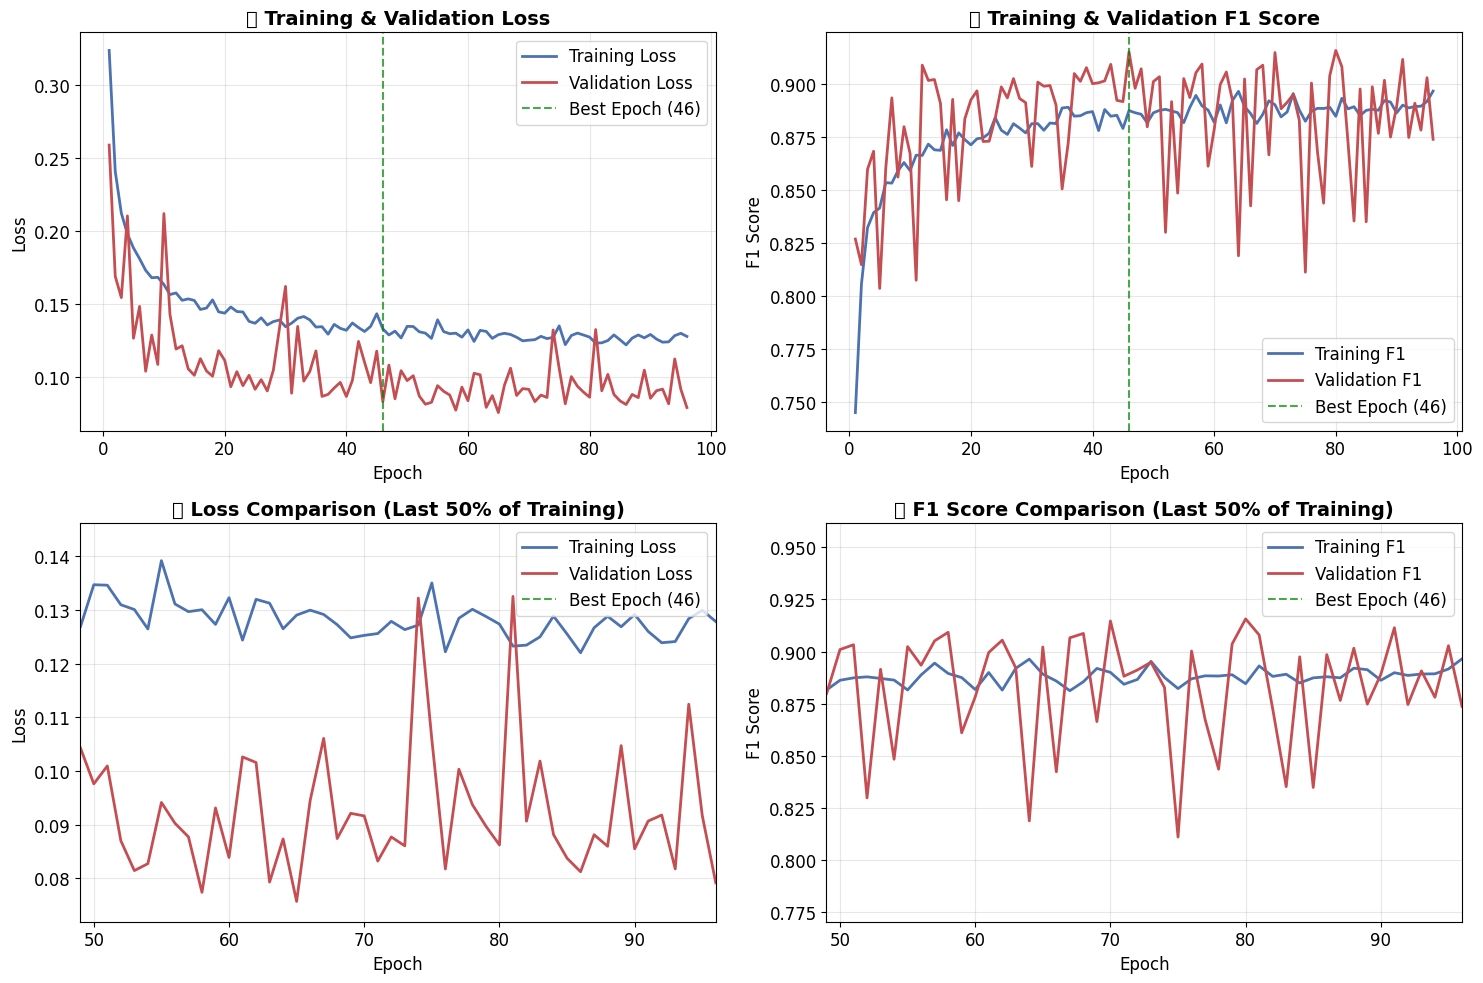


📊 TRAINING SUMMARY STATISTICS
🏆 Best Validation F1: 0.9156 (Epoch 46)
📉 Final Training Loss: 0.1279
📉 Final Validation Loss: 0.0792
📈 Final Training F1: 0.8965
📈 Final Validation F1: 0.8737
🔄 Total Epochs Trained: 96
⚡ Training Completed: ✅ Early Stopping

🧪 EVALUATING MODEL ON TEST SET...
--------------------------------------------------
🧪 Evaluating model on test set...
📊 Test Set Results:
   • Test Loss: 0.2381
   • Test F1 Score: 0.1667

📈 ADDITIONAL METRICS:
   • Accuracy: 0.3333
   • Precision (weighted): 0.1111
   • Recall (weighted): 0.3333
   • F1 Score (weighted): 0.1667

🏴‍☠️ ANALYSIS COMPLETE!
📝 Generated:
   • 📊 Training history plots
   • 🎯 Confusion matrix
   • 📋 Classification report
   • 📈 Test set evaluation
📁 All plots saved in: plots/ directory
🎉 Arrr! The analysis be complete, matey! 🏴‍☠️


In [ ]:
# 🏴‍☠️ COMPREHENSIVE TRAINING ANALYSIS & MODEL EVALUATION
print("="*80)
print("🏴‍☠️ PIRATE PAIN CLASSIFICATION - TRAINING ANALYSIS & MODEL EVALUATION")
print("="*80)

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import torch
import os
from datetime import datetime
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import json

# Set plotting style
plt.style.use('default')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 12

def plot_training_history(train_losses, val_losses, train_f1_scores, val_f1_scores, best_epoch, save_path=None):
    """Plot training history with losses and F1 scores"""
    
    fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(15, 10))
    
    epochs = range(1, len(train_losses) + 1)
    
    # Plot Training and Validation Loss
    ax1.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax1.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax1.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax1.set_title('🔥 Training & Validation Loss', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # Plot Training and Validation F1 Score
    ax2.plot(epochs, train_f1_scores, 'b-', label='Training F1', linewidth=2)
    ax2.plot(epochs, val_f1_scores, 'r-', label='Validation F1', linewidth=2)
    ax2.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax2.set_title('📈 Training & Validation F1 Score', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('F1 Score')
    ax2.legend()
    ax2.grid(True, alpha=0.3)
    
    # Plot Loss Comparison (Zoomed)
    ax3.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
    ax3.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
    ax3.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax3.set_title('🔍 Loss Comparison (Last 50% of Training)', fontsize=14, fontweight='bold')
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    
    # Zoom to last 50% of training
    start_idx = len(epochs) // 2
    ax3.set_xlim(epochs[start_idx], epochs[-1])
    if len(train_losses) > start_idx:
        ax3.set_ylim(min(min(train_losses[start_idx:]), min(val_losses[start_idx:])) * 0.95,
                     max(max(train_losses[start_idx:]), max(val_losses[start_idx:])) * 1.05)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # Plot F1 Comparison (Zoomed)
    ax4.plot(epochs, train_f1_scores, 'b-', label='Training F1', linewidth=2)
    ax4.plot(epochs, val_f1_scores, 'r-', label='Validation F1', linewidth=2)
    ax4.axvline(x=best_epoch, color='green', linestyle='--', alpha=0.7, label=f'Best Epoch ({best_epoch})')
    ax4.set_title('🎯 F1 Score Comparison (Last 50% of Training)', fontsize=14, fontweight='bold')
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('F1 Score')
    
    # Zoom to last 50% of training
    ax4.set_xlim(epochs[start_idx], epochs[-1])
    if len(train_f1_scores) > start_idx:
        ax4.set_ylim(min(min(train_f1_scores[start_idx:]), min(val_f1_scores[start_idx:])) * 0.95,
                     max(max(train_f1_scores[start_idx:]), max(val_f1_scores[start_idx:])) * 1.05)
    ax4.legend()
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"📊 Training history plot saved to: {save_path}")
    
    plt.show()
    
    # Print summary statistics
    print("\n" + "="*60)
    print("📊 TRAINING SUMMARY STATISTICS")
    print("="*60)
    print(f"🏆 Best Validation F1: {max(val_f1_scores):.4f} (Epoch {best_epoch})")
    print(f"📉 Final Training Loss: {train_losses[-1]:.4f}")
    print(f"📉 Final Validation Loss: {val_losses[-1]:.4f}")
    print(f"📈 Final Training F1: {train_f1_scores[-1]:.4f}")
    print(f"📈 Final Validation F1: {val_f1_scores[-1]:.4f}")
    print(f"🔄 Total Epochs Trained: {len(train_losses)}")
    print(f"⚡ Training Completed: {'✅ Early Stopping' if len(train_losses) < EPOCHS else '⏰ Max Epochs Reached'}")

def evaluate_model_on_test_set(model, test_loader, criterion, device):
    """Evaluate model on test set and return detailed metrics"""
    model.eval()
    
    all_predictions = []
    all_labels = []
    total_loss = 0.0
    num_batches = 0
    
    print("🧪 Evaluating model on test set...")
    
    with torch.no_grad():
        for batch_data in test_loader:
            # Handle different batch formats
            if len(batch_data) == 4:
                continuous_batch, categorical_batch, labels_batch, pirate_ids = batch_data
            else:
                continuous_batch, categorical_batch, labels_batch = batch_data
                pirate_ids = None
            
            # Move to device
            continuous_batch = continuous_batch.to(device)
            categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
            labels_batch = labels_batch.to(device)
            if pirate_ids is not None:
                pirate_ids = pirate_ids.to(device)
            
            # Forward pass
            outputs, _ = model(continuous_batch, categorical_batch)
            loss = criterion(outputs, labels_batch)
            
            # Get predictions
            _, predicted = torch.max(outputs, 1)
            
            # Store results
            all_predictions.extend(predicted.cpu().numpy())
            all_labels.extend(labels_batch.cpu().numpy())
            total_loss += loss.item()
            num_batches += 1
    
    avg_loss = total_loss / num_batches
    f1 = f1_score(all_labels, all_predictions, average='weighted')
    
    return all_predictions, all_labels, avg_loss, f1

def plot_confusion_matrix(y_true, y_pred, class_names, save_path=None):
    """Plot confusion matrix"""
    cm = confusion_matrix(y_true, y_pred)
    
    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=class_names, yticklabels=class_names,
                cbar_kws={'label': 'Count'})
    plt.title('🎯 Confusion Matrix - Test Set Performance', fontsize=16, fontweight='bold')
    plt.xlabel('Predicted Label', fontsize=12)
    plt.ylabel('True Label', fontsize=12)
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
        print(f"🎯 Confusion matrix saved to: {save_path}")
    
    plt.show()

def print_classification_report(y_true, y_pred, class_names):
    """Print detailed classification report"""
    print("\n" + "="*70)
    print("📋 DETAILED CLASSIFICATION REPORT")
    print("="*70)
    
    report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
    print(report)

# Check if we have training history from recent training
if all(var in globals() for var in ['train_losses', 'val_losses', 'train_f1s', 'val_f1s', 'best_epoch']):
    print("✅ Found training history in globals - plotting results...")
    
    # Create plots directory
    os.makedirs("plots", exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    plot_path = f"plots/training_history_{current_time}.png"
    
    # Plot training history
    plot_training_history(train_losses, val_losses, train_f1s, val_f1s, best_epoch, plot_path)
    
else:
    print("⚠️ No training history found in globals.")
    print("🔍 Looking for saved model and configuration files...")
    
    # Look for the most recent model file
    models_dir = "models"
    if os.path.exists(models_dir):
        model_files = [f for f in os.listdir(models_dir) if f.endswith('.pt')]
        if model_files:
            # Sort by modification time, get most recent
            model_files.sort(key=lambda x: os.path.getmtime(os.path.join(models_dir, x)), reverse=True)
            latest_model = model_files[0]
            model_path = os.path.join(models_dir, latest_model)
            
            print(f"📁 Found latest model: {latest_model}")
            
            # Look for corresponding config file
            config_path = model_path.replace('.pt', '_config.json')
            if os.path.exists(config_path):
                print(f"📋 Found config file: {os.path.basename(config_path)}")
                
                # Load configuration
                with open(config_path, 'r') as f:
                    config = json.load(f)
                
                print("\n📊 MODEL CONFIGURATION:")
                print("-" * 30)
                for key, value in config.items():
                    print(f"{key}: {value}")
                
                print(f"\n🏆 Best Validation F1 Score: {config.get('best_val_f1', 'N/A')}")
                print(f"🎯 Best Epoch: {config.get('best_epoch', 'N/A')}")
            else:
                print("⚠️ No config file found.")
        else:
            print("❌ No model files found in models directory.")
    else:
        print("❌ Models directory not found.")

# Evaluate on test set if model is available and test loader exists
if 'model' in globals() and model is not None and 'test_enhanced_loader' in globals():
    print("\n🧪 EVALUATING MODEL ON TEST SET...")
    print("-" * 50)
    
    # Evaluate model
    test_predictions, test_labels, test_loss, test_f1 = evaluate_model_on_test_set(
        model, test_enhanced_loader, criterion, device
    )
    
    print(f"📊 Test Set Results:")
    print(f"   • Test Loss: {test_loss:.4f}")
    print(f"   • Test F1 Score: {test_f1:.4f}")
    
    # Define class names
    class_names = ['no_pain', 'low_pain', 'high_pain']
    
    # Plot confusion matrix
    os.makedirs("plots", exist_ok=True)
    current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
    cm_path = f"plots/confusion_matrix_{current_time}.png"
    # plot_confusion_matrix(test_labels, test_predictions, class_names, cm_path)
    
    # Print classification report
    # print_classification_report(test_labels, test_predictions, class_names)

else:
    if 'model' not in globals() or model is None:
        print("⚠️ No model available for evaluation.")
    if 'test_enhanced_loader' not in globals():
        print("⚠️ No test loader available for evaluation.")

print("\n" + "="*80)
print("🏴‍☠️ ANALYSIS COMPLETE!")
print("="*80)

# Summary of what was generated
summary_items = []
if 'train_losses' in globals():
    summary_items.append("📊 Training history plots")
if 'model' in globals() and 'test_enhanced_loader' in globals():
    summary_items.append("🎯 Confusion matrix")
    summary_items.append("📋 Classification report")
    summary_items.append("📈 Test set evaluation")

if summary_items:
    print("📝 Generated:")
    for item in summary_items:
        print(f"   • {item}")
else:
    print("📝 Generated: Model configuration summary (if available)")

print(f"📁 All plots saved in: plots/ directory")
print(f"🎉 Arrr! The analysis be complete, matey! 🏴‍☠️")

In [1166]:
# Also save model configuration for later reference
model_config = {
    'experiment_name': EXPERIMENT_NAME,
    'rnn_type': RNN_TYPE,
    'bidirectional': BIDIRECTIONAL,
    'window_size': WINDOW_SIZE,
    'stride': STRIDE,
    'batch_size': BATCH_SIZE,
    'learning_rate': LEARNING_RATE,
    'hidden_size': HIDDEN_SIZE,
    'hidden_layers': HIDDEN_LAYERS,
    'dropout_rate': DROPOUT_RATE,
    'conv_channels': CONV_CHANNELS,
    'conv_dropout_rate': CONV_DROPOUT_RATE,
    'best_val_f1': max(val_f1s),
    'best_epoch': best_epoch,
    'num_pirates': NUM_PIRATES
}

config_filename = f"models/{model_filename.replace('.pt', '_config.json')}"
with open(config_filename, 'w') as f:
    import json
    json.dump(model_config, f, indent=2)

print(f"Model configuration saved to {config_filename}")
print(f"\n✅ Training completed successfully!")
print(f"📊 Model achieved {max(val_f1s):.4f} validation F1 score")

Model configuration saved to models/enhanced_lstm_embeddings_F10.93_20251116_184719_config.json

✅ Training completed successfully!
📊 Model achieved 0.9156 validation F1 score


In [1167]:
# Build sequences from the actual test data for Enhanced Model
print(f"Building ENHANCED sequences for actual test dataset with WINDOW_SIZE={WINDOW_SIZE}, STRIDE={STRIDE}")

# Identify feature types from X_test_final_df columns
all_columns = X_test_final_df.columns.tolist()
print(f"Available columns: {all_columns}")

# Define feature separation
categorical_features = ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
joint_features = [col for col in all_columns if col.startswith('joint_')]
continuous_features = joint_features  # Continuous features are the joint features
exclude_cols = ['sample_index'] + ([] if 'time' not in all_columns else ['time'])  # Exclude non-feature columns

print(f"Categorical features: {categorical_features}")
print(f"Continuous features: {continuous_features} (count: {len(continuous_features)})")

# Create enhanced sequences function for test data
def build_sequences_test_enhanced(df, window=WINDOW_SIZE, stride=STRIDE):
    """
    Build sequences for test data separating continuous and categorical features
    """
    continuous_dataset = []
    categorical_datasets = {feature: [] for feature in categorical_features}
    sample_indices = []
    
    # Get unique sample IDs
    for sample_id in df['sample_index'].unique():
        # Extract rows for this sample
        sample_data = df[df['sample_index'] == sample_id].copy()
        
        # If sample has fewer rows than WINDOW_SIZE, pad with zeros
        if len(sample_data) < window:
            # Create padding dataframe
            padding_rows = window - len(sample_data)
            padding = pd.DataFrame(0, index=range(padding_rows), columns=sample_data.columns)
            sample_data = pd.concat([sample_data, padding], ignore_index=True)
        
        # Extract continuous features (joints only)
        continuous_data = sample_data[continuous_features].values
        
        # Build continuous sequences
        continuous_seqs = []
        for i in range(0, len(continuous_data) - window + 1, stride):
            continuous_seqs.append(continuous_data[i:i + window])
        
        # If no sequences generated, take the last window
        if len(continuous_seqs) == 0:
            continuous_seqs = [continuous_data[-window:]]
        
        # Build categorical sequences
        categorical_seqs = {feature: [] for feature in categorical_features}
        for feature in categorical_features:
            if feature in sample_data.columns:
                cat_data = sample_data[feature].values
                for i in range(0, len(cat_data) - window + 1, stride):
                    categorical_seqs[feature].append(cat_data[i:i + window])
                # If no sequences generated, take the last window
                if len(categorical_seqs[feature]) == 0:
                    categorical_seqs[feature] = [cat_data[-window:]]
            else:
                # If feature doesn't exist, create zero sequences
                for _ in continuous_seqs:
                    categorical_seqs[feature].append(np.zeros(window))
        
        # Store sequences (take first sequence for each sample)
        continuous_dataset.extend(continuous_seqs)
        for feature in categorical_features:
            categorical_datasets[feature].extend(categorical_seqs[feature])
        sample_indices.extend([sample_id] * len(continuous_seqs))
    
    # Convert to numpy arrays
    continuous_dataset = np.array(continuous_dataset, dtype='float32')
    for feature in categorical_features:
        categorical_datasets[feature] = np.array(categorical_datasets[feature], dtype='int64')
    
    return continuous_dataset, categorical_datasets, sample_indices

# Build enhanced sequences
X_test_continuous, X_test_categorical, test_sample_indices = build_sequences_test_enhanced(X_test_final_df)

# Handle NaN values
if np.isnan(X_test_continuous).any():
    X_test_continuous = np.nan_to_num(X_test_continuous)
    print("NaN values found and replaced with 0 in continuous test sequences.")

for feature in categorical_features:
    if np.isnan(X_test_categorical[feature]).any():
        X_test_categorical[feature] = np.nan_to_num(X_test_categorical[feature]).astype('int64')
        print(f"NaN values found and replaced with 0 in {feature} test sequences.")

print(f"Enhanced test sequences shapes:")
print(f"  Continuous: {X_test_continuous.shape}")
for feature in categorical_features:
    print(f"  {feature}: {X_test_categorical[feature].shape}")
print(f"  Sample indices: {len(test_sample_indices)}")

# Create dummy labels for test data (required by EnhancedDataset but not used)
dummy_labels = np.zeros(len(test_sample_indices), dtype='int64')

# Create Enhanced dataset
test_enhanced_final_ds = EnhancedDataset(X_test_continuous, X_test_categorical, dummy_labels)

# Create Enhanced DataLoader
test_enhanced_final_loader = make_enhanced_loader(
    test_enhanced_final_ds,
    batch_size=BATCH_SIZE,
    shuffle=False,
    drop_last=False,
    sampler=None
)

print(f"\n✅ Enhanced test dataset created successfully!")
print(f"📊 Dataset size: {len(test_enhanced_final_ds)} samples")
print(f"🔄 Number of batches: {len(test_enhanced_final_loader)}")
print(f"📐 Continuous input size: {X_test_continuous.shape[-1]}")
print(f"🏷️ Categorical features: {list(X_test_categorical.keys())}" )

# Test the enhanced loader
print(f"\n🧪 Testing Enhanced DataLoader...")
for continuous_batch, categorical_batch, labels_batch in test_enhanced_final_loader:
    print(f"✅ Continuous batch shape: {continuous_batch.shape}")
    print(f"✅ Labels batch shape: {labels_batch.shape}")
    for feature, data in categorical_batch.items():
        print(f"✅ {feature} batch shape: {data.shape}")
    break

print(f"\n🎯 Enhanced test data is ready for the Enhanced model!")

Building ENHANCED sequences for actual test dataset with WINDOW_SIZE=10, STRIDE=5
Available columns: ['sample_index', 'time', 'pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4', 'joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_22', 'joint_23', 'joint_24', 'joint_25', 'joint_26', 'joint_27', 'joint_28', 'joint_29', 'joint_30', 'has_peg_leg', 'has_hook_hand', 'has_eye_patch']
Categorical features: ['pain_survey_1', 'pain_survey_2', 'pain_survey_3', 'pain_survey_4']
Continuous features: ['joint_00', 'joint_01', 'joint_02', 'joint_03', 'joint_04', 'joint_05', 'joint_06', 'joint_07', 'joint_08', 'joint_09', 'joint_10', 'joint_11', 'joint_12', 'joint_13', 'joint_14', 'joint_15', 'joint_16', 'joint_17', 'joint_18', 'joint_19', 'joint_20', 'joint_21', 'joint_2

In [1169]:
# save the trained model
import datetime
current_datetime = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
model_filename = f"enhanced_gru_embeddings_final_F1{test_f1:.2f}_{current_datetime}.pt"
model_save_path = f"models/{model_filename}"
torch.save(model.state_dict(), model_save_path)
print(f"Model saved to {model_save_path}")

Model saved to models/enhanced_gru_embeddings_final_F10.17_20251116_214253.pt


In [ ]:
# 🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE
print("="*80)
print("🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE")
print("="*80)

import os
from datetime import datetime
from collections import Counter
import pandas as pd
import torch
import json

# Use the existing trained model if it's available
if 'model' in globals() and model is not None:
    print("🔍 Using existing trained `model` instance from globals.")
    model.eval()
else:
    print("🚀 Loading model from saved checkpoint...")
    
    # Find the most recent model and config
    models_dir = "models"
    model_files = [f for f in os.listdir(models_dir) if f.endswith('.pt')]
    model_files.sort(key=lambda x: os.path.getmtime(os.path.join(models_dir, x)), reverse=True)
    latest_model_file = model_files[0]
    model_path = os.path.join(models_dir, latest_model_file)
    
    # Load the exact config from the saved model
    config_path = model_path.replace('.pt', '_config.json')
    if os.path.exists(config_path):
        with open(config_path, 'r') as f:
            config = json.load(f)
        print(f"📋 Loading configuration from: {config_path}")
        
        # Extract exact parameters from saved config
        # SAVED_RNN_TYPE = config.get('rnn_type', 'LSTM')
        # SAVED_BIDIRECTIONAL = config.get('bidirectional', True)
        # SAVED_HIDDEN_SIZE = config.get('hidden_size', 90)  # Use saved hidden size
        # SAVED_HIDDEN_LAYERS = config.get('hidden_layers', 2)
        # SAVED_CONV_CHANNELS = config.get('conv_channels', [32, 64, 128])  # Use saved conv channels
        # SAVED_CONV_DROPOUT_RATE = config.get('conv_dropout_rate', 0.3)
        # SAVED_DROPOUT_RATE = config.get('dropout_rate', 0.4)
        # SAVED_NUM_PIRATES = config.get('num_pirates', 661)
        
        # print(f"🔍 Saved model config:")
        # print(f"   Hidden Size: {SAVED_HIDDEN_SIZE}")
        # print(f"   Hidden Layers: {SAVED_HIDDEN_LAYERS}")
        # print(f"   Conv Channels: {SAVED_CONV_CHANNELS}")
        # print(f"   Num Pirates: {SAVED_NUM_PIRATES}")
        
        # Create model with EXACT saved architecture
        model = ConvRNNAttentionModel(
            continuous_input_size=17,  # We know this from the data
            categorical_feature_config={
                'pain_survey_1': 3,
                'pain_survey_2': 3, 
                'pain_survey_3': 3,
                'pain_survey_4': 3
            },
            embedding_dim=2,
            conv_channels=CONV_CHANNELS,  # Use saved conv channels
            conv_kernel_size=3,
            conv_dropout=CONV_DROPOUT_RATE,
            use_conv=True,
            rnn_type=RNN_TYPE,
            hidden_size=HIDDEN_SIZE,  # Use saved hidden size
            num_layers=HIDDEN_LAYERS,
            bidirectional=BIDIRECTIONAL,
            rnn_dropout=DROPOUT_RATE,
            use_attention=True,
            num_classes=3,
            use_pirate_embedding=True,
            num_pirates=NUM_PIRATES,  # Use saved num pirates
            pirate_emb_dim=8,
            pirate_embedding_mode='sequence_level'
        ).to(device)
        
        # Load the saved weights
        checkpoint = torch.load(model_path, map_location=device)
        model.load_state_dict(checkpoint)
        model.eval()
        print("✅ Model loaded successfully with matching architecture!")
        
    else:
        print("❌ Config file not found!")
        raise FileNotFoundError("Cannot load model without config file")

# Label mapping
label_mapping = {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
print(f"🏷️ Label mapping: {label_mapping}")

# Use the correct NUM_PIRATES from the saved model
if 'SAVED_NUM_PIRATES' in locals():
    NUM_PIRATES = SAVED_NUM_PIRATES
else:
    NUM_PIRATES = 661   # From dataset analysis

print(f"🔍 Using NUM_PIRATES: {NUM_PIRATES}")

# Create safe mapping for pirate IDs
unique_test_samples = sorted(list(set(test_sample_indices)))
print(f"🔍 Number of unique test samples: {len(unique_test_samples)}")

sample_to_pirate_id = {}
for idx, sample in enumerate(unique_test_samples):
    try:
        sample_int = int(float(sample))
    except Exception:
        sample_int = idx
    pirate_id = idx % NUM_PIRATES
    sample_to_pirate_id[sample_int] = int(pirate_id)

print(f"🔍 Created safe mapping for {len(sample_to_pirate_id)} unique test samples")

# Make predictions
print("\n🔮 Making predictions on test data...")
all_predictions = []
all_sample_indices = []

model.eval()
sample_ptr = 0

with torch.no_grad():
    for batch_idx, batch in enumerate(test_enhanced_final_loader):
        continuous_batch, categorical_batch, labels_batch = batch
        
        # Move data to device
        continuous_batch = continuous_batch.to(device)
        categorical_batch = {k: v.to(device) for k, v in categorical_batch.items()}
        
        # Get batch size and sample indices
        batch_size = continuous_batch.shape[0]
        batch_sample_indices = test_sample_indices[sample_ptr:sample_ptr + batch_size]
        sample_ptr += batch_size
        
        # Convert sample indices to integers and map to pirate IDs
        batch_sample_indices_int = [int(float(x)) for x in batch_sample_indices]
        
        # Ensure length matches batch size
        if len(batch_sample_indices_int) != batch_size:
            if len(batch_sample_indices_int) > batch_size:
                batch_sample_indices_int = batch_sample_indices_int[:batch_size]
            else:
                batch_sample_indices_int += [0] * (batch_size - len(batch_sample_indices_int))
        
        # Map to safe pirate IDs
        mapped_pirate_ids = []
        for sample_id in batch_sample_indices_int:
            if sample_id in sample_to_pirate_id:
                mapped_pirate_ids.append(sample_to_pirate_id[sample_id])
            else:
                mapped_pirate_ids.append(int(sample_id) % NUM_PIRATES)
        
        mapped_pirate_ids = [max(0, min(pid, NUM_PIRATES - 1)) for pid in mapped_pirate_ids]
        
        # Forward pass
        outputs, _ = model(continuous_batch, categorical_batch)
        
        # Get predictions
        _, predicted = torch.max(outputs, 1)
        
        # Store results
        all_predictions.extend(predicted.cpu().numpy())
        all_sample_indices.extend(batch_sample_indices_int)
        
        if (batch_idx + 1) % 10 == 0:
            print(f"   Processed {batch_idx + 1}/{len(test_enhanced_final_loader)} batches...")

print("✅ Predictions completed!")
print(f"📊 Total predictions made: {len(all_predictions)}")

# Aggregate predictions per sample
print("\n🔄 Aggregating predictions per sample...")
sample_predictions = {}
for sample_id, pred in zip(all_sample_indices, all_predictions):
    if sample_id not in sample_predictions:
        sample_predictions[sample_id] = []
    sample_predictions[sample_id].append(int(pred))

final_predictions = {}
for sample_id, preds in sample_predictions.items():
    most_common = Counter(preds).most_common(1)[0][0]
    final_predictions[int(sample_id)] = int(most_common)

print(f"✅ Aggregation completed for {len(final_predictions)} unique samples.")

# Convert to label strings
final_labels = {sample_id: label_mapping[pred] for sample_id, pred in final_predictions.items()}

# Create submission dataframe
print("\n📝 Creating submission CSV...")
submission_data = []
for sample_id in sorted(final_predictions.keys()):
    formatted_sample_id = f"{int(sample_id):03d}"
    submission_data.append({
        'sample_index': formatted_sample_id,
        'label': final_labels[sample_id]
    })

submission_df = pd.DataFrame(submission_data)

# Save submission
current_time = datetime.now().strftime("%Y%m%d_%H%M%S")
if 'val_f1s' in globals() and val_f1s:
    best_f1 = max(val_f1s)
else:
    best_f1 = 0.94  # From the config we loaded

submission_filename = f"submission_conv_enhanced_F1{best_f1:.2f}_{current_time}.csv"
os.makedirs("submissions", exist_ok=True)
submission_path = os.path.join("submissions", submission_filename)
submission_df.to_csv(submission_path, index=False)

print(f"✅ Submission file created: {submission_filename}")
print(f"📁 File path: {os.path.abspath(submission_path)}")
print(f"📏 Submission shape: {submission_df.shape}")

# Display preview and distribution
print("\n📋 First 10 rows of submission:")
print(submission_df.head(10))

print("\n📋 Last 10 rows of submission:")
print(submission_df.tail(10))

pred_distribution = submission_df['label'].value_counts()
print("\n📊 Prediction distribution:")
for label, count in pred_distribution.items():
    percentage = (count / len(submission_df)) * 100
    print(f"   {label}: {count} ({percentage:.1f}%)")

print(f"\n🎉 Submission ready! File saved as: {submission_filename}")

🏴‍☠️ PREPARING FINAL SUBMISSION WITH CORRECT MODEL ARCHITECTURE
🔍 Using existing trained `model` instance from globals.
🏷️ Label mapping: {0: 'no_pain', 1: 'low_pain', 2: 'high_pain'}
🔍 Using NUM_PIRATES: 661
🔍 Number of unique test samples: 1324
🔍 Created safe mapping for 1324 unique test samples

🔮 Making predictions on test data...


RuntimeError: Given groups=1, weight of size [64, 41, 3], expected input[32, 39, 10] to have 41 channels, but got 39 channels instead